In [38]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import re
import os
import glob
import seaborn as sns
import io
import statistics

# 28S ExpansionSegments
data = np.array([
    ['ESL5', 'ESL7', 'ESL9', 'ESL10', 'ESL12', 'ESL15', 'ESL19', 'ESL20', 'ESL24', 'ESL26', 'ESL27', 'ESL30', 'ESL31', 'ESL39', 'ESL41'],
    [114, 465, 1384, 1682, 1793, 2075, 2439, 2538, 2685, 2751, 2875, 3955, 4057, 4698, 4983],
    [156, 1265, 1487, 1711, 1829, 2256, 2494, 2575, 2705, 2764, 3586, 4013, 4124, 4905, 4996]
])

df1 = pd.DataFrame(data.T, columns=['Segment', 'Start', 'End'])
df1['Start'] = pd.to_numeric(df1['Start']) + 7935
df1['End'] = pd.to_numeric(df1['End']) + 7935

# 18S ExpansionSegments
data = np.array([
    ['ESS1', 'ESS2', 'ESS3', 'ESS4', 'ESS6', 'ESS7', 'ESS8', 'ESS9', 'ESS10', 'ESS11', 'ESS12'],
    [53, 116, 208, 512, 737, 1097, 1272, 1398, 1533, 1563, 1726],
    [73, 130, 291, 583, 911, 1114, 1305, 1403, 1551, 1581, 1789]
])

df2 = pd.DataFrame(data.T, columns=['Segment', 'Start', 'End'])
df2['Start'] = pd.to_numeric(df2['Start']) + 3657
df2['End'] = pd.to_numeric(df2['End']) + 3657

df3 = pd.read_csv(r'/Users/fionachow/Documents/NYU/CDS/Summer 2024/Human rDNA Research/Project/Human-rDNA/original reference/homopolymers.csv')

df4 = pd.read_csv(r'/Users/fionachow/Documents/NYU/CDS/Summer 2024/Human rDNA Research/Project/Human-rDNA/original reference/Copy of conserve - Sheet1.csv')

df5 = pd.read_csv(r'/Users/fionachow/Documents/NYU/CDS/Summer 2024/Human rDNA Research/Project/Human-rDNA/outputs/src_outputs/pg_positions_2.csv', sep=',', skipinitialspace=True, engine='python')

# for new vcf headers
def read_txt2(path, y_axis='AF_new'): #modified here to include y_axis parameter
    df = pd.read_csv(path)
    fxhold = df['POS'].tolist()
    refhold = df['new_ref'].tolist()
    althold = df['ALT_new'].tolist()
    fhold = df[y_axis].tolist() # normalized AF or AF_new
    return fhold, fxhold, refhold, althold

def get_rRNA_bounds(gb_file_path):
    gb_file = open(gb_file_path)
    pattern_1 = r'^\s+rRNA'
    pattern_2 = r'\d+'
    points = []
    for line in gb_file:
        if re.search(pattern_1, line):
            send = re.findall(pattern_2, line)
            points.append([int(send[0]), int(send[1])])
    return points

gb_file_path = '/Users/fionachow/Documents/NYU/CDS/Summer 2024/Human rDNA Research/Project/Human-rDNA/original reference/U13369.1_Human_rDNA_repeat_unit.gb'
vcf_directory = '/Users/fionachow/Documents/NYU/CDS/Summer 2024/Human rDNA Research/Project/Human-rDNA/outputs/src_outputs/new_vcf/full_set'
og_vcf_directory = '/Users/fionachow/Documents/NYU/CDS/Summer 2024/Human rDNA Research/Project/Human-rDNA/original reference/original_vcf_all'

skipped_files_path = os.path.join(vcf_directory, 'skipped_files.csv')

if os.path.exists(skipped_files_path):
    skipped_files_df = pd.read_csv(skipped_files_path)
    skipped_files = set(skipped_files_df['Run'].apply(lambda x: f"new_vcf_{x}.csv"))
else:
    skipped_files = set()

if os.path.isdir(vcf_directory):
    vcf_files = [os.path.join(vcf_directory, file) for file in os.listdir(vcf_directory) if file.startswith('new') and file not in skipped_files]
else:
    raise ValueError(f"{vcf_directory} is not a valid directory")

# Get rRNA positions
rRNA_positions = get_rRNA_bounds(gb_file_path)
zoomed_range = [rRNA_positions[0][0] - 100, rRNA_positions[-1][-1] + 100]

expansion_positions1 = []
for row in df1.iterrows():
    hold = []
    hold.append(row[1]['Start'])
    hold.append(row[1]['End'])
    expansion_positions1.append(hold)

expansion_positions2 = []
for row in df2.iterrows():
    hold = []
    hold.append(row[1]['Start'])
    hold.append(row[1]['End'])
    expansion_positions2.append(hold)

hmplr_pos = []
for row in df3.iterrows():
    hold = []
    hold.append(row[1]['Start'])
    hold.append(row[1]['End'])
    hmplr_pos.append(hold)

csvd_pos = []
for row in df4.iterrows():
    hold = []
    hold.append(row[1]['Start'])
    hold.append(row[1]['End'])
    csvd_pos.append(hold)

/var/folders/hb/l21bg8lx3tgc5ky3s56cwdth0000gn/T/ipykernel_52943/2906442913.py:120: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()
/var/folders/hb/l21bg8lx3tgc5ky3s56cwdth0000gn/T/ipykernel_52943/2906442913.py:121: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.savefig("new_vcf.pdf", format="pdf", bbox_inches="tight")
/var/folders/hb/l21bg8lx3tgc5ky3s56cwdth0000gn/T/ipykernel_52943/2906442913.py:121: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.savefig("new_vcf.pdf", format="pdf", bbox_inches="tight")


Total unique positions across all samples: 7830
Total unique allele combinations (position, ref, alt) across all samples: 11198


/Users/fionachow/opt/anaconda3/envs/bloom/lib/python3.9/site-packages/IPython/core/pylabtools.py:152: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


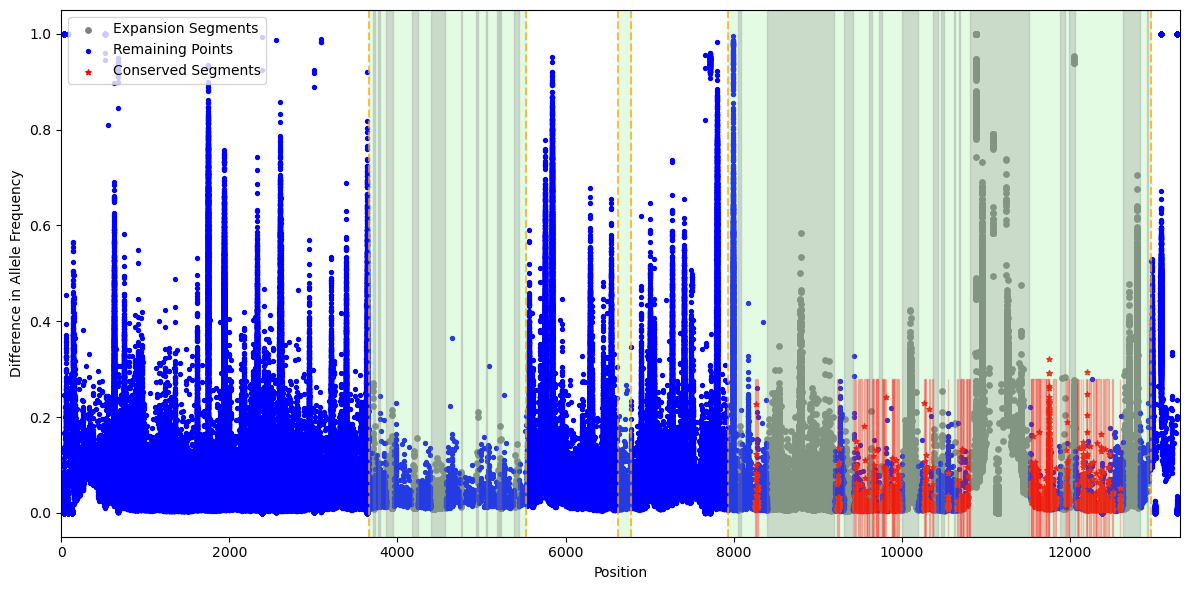

In [39]:
#plotting new vcf manhattan plot for all samples 

# Initialize sets for unique positions and unique alleles (position, ref, alt)
unique_positions = set()
unique_alleles = set()

# Initialize lists to store scatter data
grey_x, grey_y, blue_x, blue_y, red_x, red_y, white_x, white_y = [], [], [], [], [], [], [], []

plt.figure(figsize=(12, 6))
for file in vcf_files:
    hold, xhold, rh, ah = read_txt2(file)

    # Track unique positions and alleles
    unique_positions.update(xhold)  # Add all positions to unique positions set
    unique_alleles.update(zip(xhold, rh, ah))  # Add unique (position, ref, alt) tuples to unique alleles set

    grey_x_temp = []
    grey_y_temp = []
    blue_x_temp = []
    blue_y_temp = []
    red_x_temp = []
    red_y_temp = []
    white_x_temp = []
    white_y_temp = []

    # Modified here: Include 'Ref' and 'Alt' in data DataFrame
    data = pd.DataFrame({'x': xhold, 'y': hold, 'Ref': rh, 'Alt': ah})

    # Processing 28S segments
    for _, segment in df1.iterrows():
        start, end = segment['Start'], segment['End']
        mask = (data['x'] >= start) & (data['x'] <= end)
        selected_data = data[mask]
        grey_x_temp.extend(selected_data['x'].tolist())
        grey_y_temp.extend(selected_data['y'].tolist())
        data = data[~mask]

    # Processing 18S segments
    for _, segment in df2.iterrows():
        start, end = segment['Start'], segment['End']
        mask2 = (data['x'] >= start) & (data['x'] <= end)
        selected_data2 = data[mask2]
        grey_x_temp.extend(selected_data2['x'].tolist())
        grey_y_temp.extend(selected_data2['y'].tolist())
        data = data[~mask2]

    # Processing homopolymer segments
    for _, segment in df3.iterrows():
        start, end = segment['Start'], segment['End']
        mask3 = (data['x'] >= start) & (data['x'] <= end)
        selected_data3 = data[mask3]
        white_x_temp.extend(selected_data3['x'].tolist())
        white_y_temp.extend(selected_data3['y'].tolist())
        data = data[~mask3]

    # Processing conserved segments
    for _, segment in df4.iterrows():
        start, end = segment['Start'], segment['End']
        mask4 = (data['x'] >= start) & (data['x'] <= end)
        selected_data4 = data[mask4]
        red_x_temp.extend(selected_data4['x'].tolist())
        red_y_temp.extend(selected_data4['y'].tolist())
        data = data[~mask4]

    # Modified here: Processing pseudogene segments with Ref and Alt matching
    for _, segment in df5.iterrows():
        start, end = segment['Start'], segment['End']
        ref_seg = segment['Ref']
        alt_seg = segment['Alt']
        mask5 = (
            (data['x'] >= start) &
            (data['x'] <= end) &
            (data['Ref'] == ref_seg) &
            (data['Alt'] == alt_seg)
        )
        selected_data5 = data[mask5]
        white_x_temp.extend(selected_data5['x'].tolist())
        white_y_temp.extend(selected_data5['y'].tolist())
        data = data[~mask5]

    # Remaining points are blue points
    blue_x_temp.extend(data['x'].tolist())
    blue_y_temp.extend(data['y'].tolist())

    grey_x.extend(grey_x_temp)
    grey_y.extend(grey_y_temp)
    blue_x.extend(blue_x_temp)
    blue_y.extend(blue_y_temp)
    red_x.extend(red_x_temp)
    red_y.extend(red_y_temp)
    white_x.extend(white_x_temp)
    white_y.extend(white_y_temp)

# Plot grey points, blue points, and red stars
plt.scatter(grey_x, grey_y, s=15, color='Gray', label='Expansion Segments')
plt.scatter(blue_x, blue_y, s=8, color='Blue', label='Remaining Points')
plt.scatter(red_x, red_y, s=15, color='Red', marker='*', label='Conserved Segments')
plt.scatter(white_x, white_y, s=8, color='white', alpha=0)

# Add vertical lines and shaded regions
for start, end in rRNA_positions:
    plt.axvline(x=start, color='orange', linestyle='--', alpha=0.7)
    plt.axvline(x=end, color='orange', linestyle='--', alpha=0.7)
    plt.axvspan(start, end, alpha=0.25, color='lightgreen')

for start, end in expansion_positions2:
    plt.axvspan(start, end, alpha=0.25, color='grey')

for start, end in expansion_positions1:
    plt.axvspan(start, end, alpha=0.25, color='grey')

for start, end in csvd_pos:
    plt.axvspan(start, end, 0, 0.3, alpha=0.25, color='red')

plt.xlabel('Position')
plt.ylabel('Difference in Allele Frequency')
plt.xlim(0, 13314)
plt.legend()
plt.tight_layout()
plt.savefig("new_vcf.pdf", format="pdf", bbox_inches="tight")
# plt.show()

print(f"Total unique positions across all samples: {len(unique_positions)}")
print(f"Total unique allele combinations (position, ref, alt) across all samples: {len(unique_alleles)}")


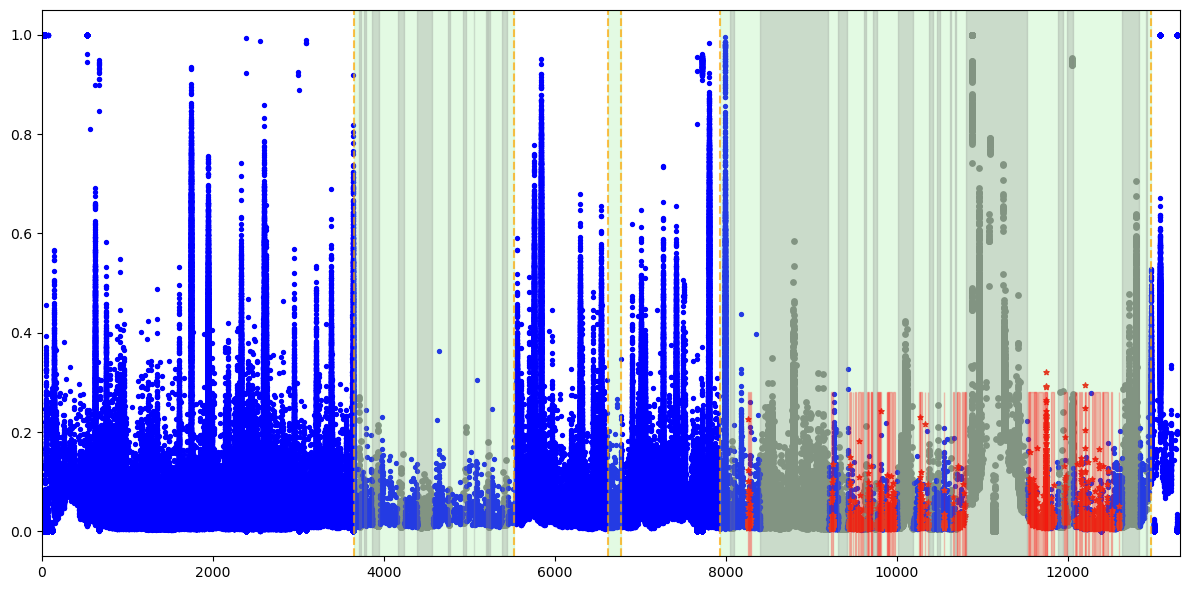

In [44]:
# Same plot as above but no labels
# Plot grey points, blue points, and red stars
plt.figure(figsize=(12, 6))
plt.scatter(grey_x, grey_y, s=15, color='Gray', label='Expansion Segments')
plt.scatter(blue_x, blue_y, s=8, color='Blue', label='Remaining Points')
plt.scatter(red_x, red_y, s=15, color='Red', marker='*', label='Conserved Segments')
plt.scatter(white_x, white_y, s=8, color='white', alpha=0)

# Add vertical lines and shaded regions
for start, end in rRNA_positions:
    plt.axvline(x=start, color='orange', linestyle='--', alpha=0.7)
    plt.axvline(x=end, color='orange', linestyle='--', alpha=0.7)
    plt.axvspan(start, end, alpha=0.25, color='lightgreen')

for start, end in expansion_positions2:
    plt.axvspan(start, end, alpha=0.25, color='grey')

for start, end in expansion_positions1:
    plt.axvspan(start, end, alpha=0.25, color='grey')

for start, end in csvd_pos:
    plt.axvspan(start, end, 0, 0.3, alpha=0.25, color='red')

plt.xlim(0, 13314)
plt.tight_layout()
plt.savefig("new_vcf_nolabels.pdf", format="pdf", bbox_inches="tight")


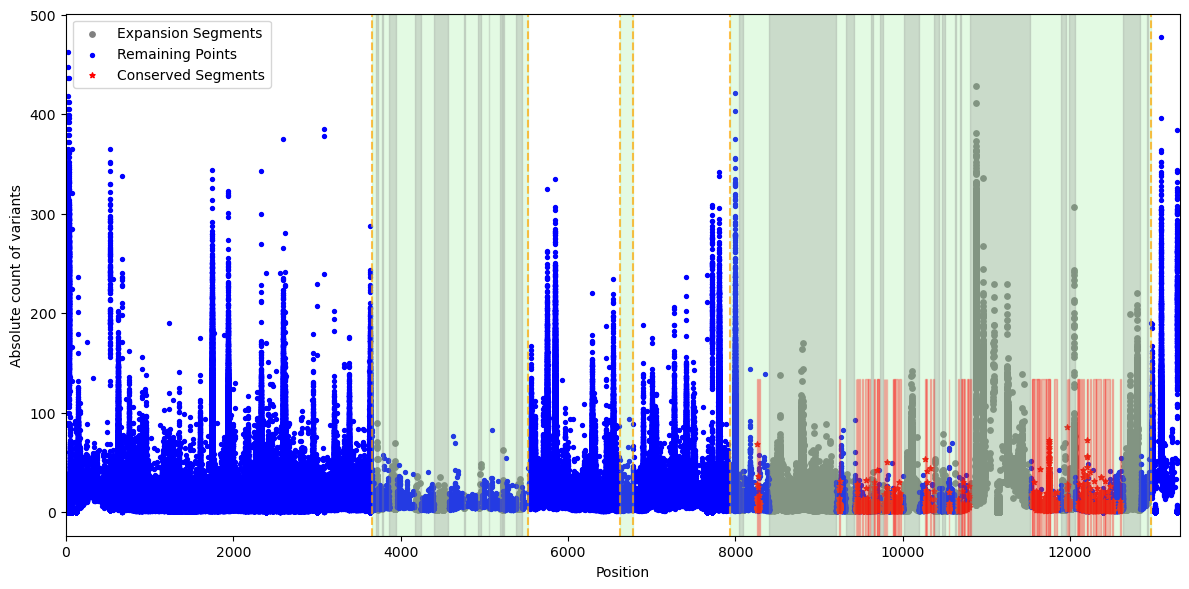

In [45]:
#plotting new vcf (w normalized AF) - similar to above code block

# Initialize lists to store scatter data
grey_x, grey_y, blue_x, blue_y, red_x, red_y, white_x, white_y = [], [], [], [], [], [], [], []

# Plotting section
plt.figure(figsize=(12, 6))
for file in vcf_files:
    hold, xhold, rh, ah = read_txt2(file, y_axis='normalized AF') # Modified here to include y_axis params for respective use case

    grey_x_temp = []
    grey_y_temp = []
    blue_x_temp = []
    blue_y_temp = []
    red_x_temp = []
    red_y_temp = []
    white_x_temp = []
    white_y_temp = []
    
    # Modified here: Include 'Ref' and 'Alt' in data DataFrame
    data = pd.DataFrame({'x': xhold, 'y': hold, 'Ref': rh, 'Alt': ah})

    # Processing 28S segments
    for _, segment in df1.iterrows():
        start, end = segment['Start'], segment['End']
        mask = (data['x'] >= start) & (data['x'] <= end)
        selected_data = data[mask]
        grey_x_temp.extend(selected_data['x'].tolist())
        grey_y_temp.extend(selected_data['y'].tolist())
        data = data[~mask]
    
    # Processing 18S segments
    for _, segment in df2.iterrows():
        start, end = segment['Start'], segment['End']
        mask2 = (data['x'] >= start) & (data['x'] <= end)
        selected_data2 = data[mask2]
        grey_x_temp.extend(selected_data2['x'].tolist())
        grey_y_temp.extend(selected_data2['y'].tolist())
        data = data[~mask2]
    
    # Processing homopolymer segments
    for _, segment in df3.iterrows():
        start, end = segment['Start'], segment['End']
        mask3 = (data['x'] >= start) & (data['x'] <= end)
        selected_data3 = data[mask3]
        white_x_temp.extend(selected_data3['x'].tolist())
        white_y_temp.extend(selected_data3['y'].tolist())
        data = data[~mask3]
    
    # Processing conserved segments
    for _, segment in df4.iterrows():
        start, end = segment['Start'], segment['End']
        mask4 = (data['x'] >= start) & (data['x'] <= end)
        selected_data4 = data[mask4]
        red_x_temp.extend(selected_data4['x'].tolist())
        red_y_temp.extend(selected_data4['y'].tolist())
        data = data[~mask4]

    # Modified here: Processing pseudogene segments with Ref and Alt matching
    for _, segment in df5.iterrows():
        start, end = segment['Start'], segment['End']
        ref_seg = segment['Ref']
        alt_seg = segment['Alt']
        mask5 = (
            (data['x'] >= start) &
            (data['x'] <= end) &
            (data['Ref'] == ref_seg) &
            (data['Alt'] == alt_seg)
        )
        selected_data5 = data[mask5]
        white_x_temp.extend(selected_data5['x'].tolist())
        white_y_temp.extend(selected_data5['y'].tolist())
        data = data[~mask5]

    # Remaining points are blue points
    blue_x_temp.extend(data['x'].tolist())
    blue_y_temp.extend(data['y'].tolist())

    grey_x.extend(grey_x_temp)
    grey_y.extend(grey_y_temp)
    blue_x.extend(blue_x_temp)
    blue_y.extend(blue_y_temp)
    red_x.extend(red_x_temp)
    red_y.extend(red_y_temp)
    white_x.extend(white_x_temp)
    white_y.extend(white_y_temp)

# Plot grey points, blue points, and red stars
plt.scatter(grey_x, grey_y, s=15, color='Gray', label='Expansion Segments')
plt.scatter(blue_x, blue_y, s=8, color='Blue', label='Remaining Points')
plt.scatter(red_x, red_y, s=15, color='Red', marker='*', label='Conserved Segments')
plt.scatter(white_x, white_y, s=8, color='white', alpha=0)

# Add vertical lines and shaded regions
for start, end in rRNA_positions:
    plt.axvline(x=start, color='orange', linestyle='--', alpha=0.7)
    plt.axvline(x=end, color='orange', linestyle='--', alpha=0.7)
    plt.axvspan(start, end, alpha=0.25, color='lightgreen')

for start, end in expansion_positions2:
    plt.axvspan(start, end, alpha=0.25, color='grey')

for start, end in expansion_positions1:
    plt.axvspan(start, end, alpha=0.25, color='grey')

for start, end in csvd_pos:
    plt.axvspan(start, end, 0, 0.3, alpha=0.25, color='red')

plt.xlabel('Position')
plt.ylabel('Absolute count of variants')
plt.xlim(0, 13314)
plt.legend()
plt.tight_layout()
plt.savefig("new_vcf_normalized.pdf", format="pdf", bbox_inches="tight")
# plt.show()

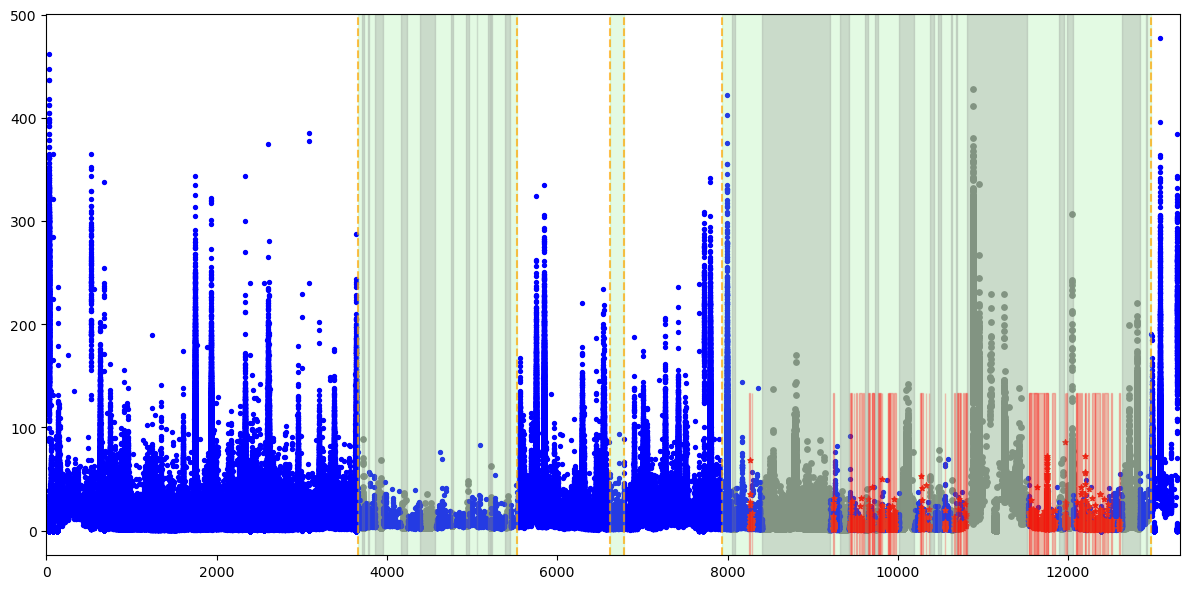

In [46]:
# Same plot as above but no labels
plt.figure(figsize=(12, 6))
# Plot grey points, blue points, and red stars
plt.scatter(grey_x, grey_y, s=15, color='Gray', label='Expansion Segments')
plt.scatter(blue_x, blue_y, s=8, color='Blue', label='Remaining Points')
plt.scatter(red_x, red_y, s=15, color='Red', marker='*', label='Conserved Segments')
plt.scatter(white_x, white_y, s=8, color='white', alpha=0)

# Add vertical lines and shaded regions
for start, end in rRNA_positions:
    plt.axvline(x=start, color='orange', linestyle='--', alpha=0.7)
    plt.axvline(x=end, color='orange', linestyle='--', alpha=0.7)
    plt.axvspan(start, end, alpha=0.25, color='lightgreen')

for start, end in expansion_positions2:
    plt.axvspan(start, end, alpha=0.25, color='grey')

for start, end in expansion_positions1:
    plt.axvspan(start, end, alpha=0.25, color='grey')

for start, end in csvd_pos:
    plt.axvspan(start, end, 0, 0.3, alpha=0.25, color='red')

plt.xlim(0, 13314)
plt.tight_layout()
plt.savefig("new_vcf_normalized_nolabels.pdf", format="pdf", bbox_inches="tight")

In [47]:
def read_vcf(path):
    with open(path, 'r') as f:
        lines = [l for l in f if not l.startswith('##')]
    return pd.read_csv(
        io.StringIO(''.join(lines)),
        dtype={'#CHROM': str, 'POS': int, 'ID': str, 'REF': str, 'ALT': str,
               'QUAL': str, 'FILTER': str, 'INFO': str},
        sep='\t'
    ).rename(columns={'#CHROM': 'CHROM'})

def extract_af(info):
    match = re.search(r'AF=([\d\.]+)', info)
    return match.group(1) if match else None

# for og vcf headers 
def read_txt3(df, y_axis='AF'): # Modified here: to include y_axis param 
    df = df[(df['REF'].str.len()) == (df['ALT'].str.len())]
    fxhold = df['POS'].tolist()
    refhold = df['REF'].tolist()
    althold = df['ALT'].tolist()
    fhold = df[y_axis].tolist()
    return fhold, fxhold, refhold, althold

modified_og_vcf_directory = '/Users/fionachow/Documents/NYU/CDS/Summer 2024/Human rDNA Research/Project/Human-rDNA/outputs/src_outputs/modified_original_reference'

skipped_files_path = os.path.join(modified_og_vcf_directory, 'skipped_files.csv')

if os.path.exists(skipped_files_path):
    skipped_files_df = pd.read_csv(skipped_files_path)
    skipped_files = set(skipped_files_df['Run'].apply(lambda x: f"{x}_rDNA.vcf"))
else:
    skipped_files = set()

if os.path.isdir(og_vcf_directory):
    vcf_files = [os.path.join(og_vcf_directory, file) for file in os.listdir(og_vcf_directory) if file.startswith('E') and file not in skipped_files]
else:
    raise ValueError(f"{og_vcf_directory} is not a valid directory")

/var/folders/hb/l21bg8lx3tgc5ky3s56cwdth0000gn/T/ipykernel_52943/3327770378.py:124: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()
/var/folders/hb/l21bg8lx3tgc5ky3s56cwdth0000gn/T/ipykernel_52943/3327770378.py:125: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.savefig("og_vcf.pdf", format="pdf", bbox_inches="tight")
/var/folders/hb/l21bg8lx3tgc5ky3s56cwdth0000gn/T/ipykernel_52943/3327770378.py:125: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.savefig("og_vcf.pdf", format="pdf", bbox_inches="tight")


Total unique positions across all samples: 7885
Total unique allele combinations (position, ref, alt) across all samples: 11325


/Users/fionachow/opt/anaconda3/envs/bloom/lib/python3.9/site-packages/IPython/core/pylabtools.py:152: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


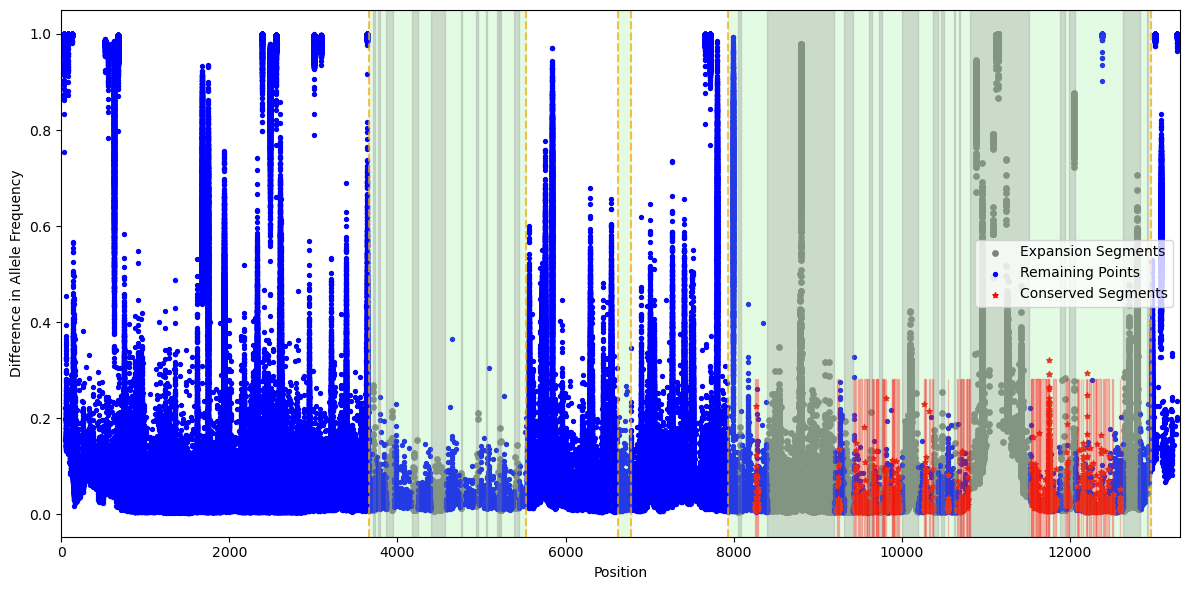

In [48]:
#using original vcfs (just SNPs) for baseline comparison

# Initialize sets for unique positions and unique alleles (position, ref, alt)
unique_positions = set()
unique_alleles = set()

# Initialize lists to store scatter data
grey_x, grey_y, blue_x, blue_y, red_x, red_y, white_x, white_y = [], [], [], [], [], [], [], []

# Plotting section
plt.figure(figsize=(12, 6))
for file in vcf_files:
    individual_df = read_vcf(file)
    individual_df['AF'] = individual_df['INFO'].apply(extract_af)
    individual_df['AF'] = individual_df['AF'].astype(float)
    hold, xhold, rh, ah = read_txt3(individual_df)

    # Track unique positions and alleles
    unique_positions.update(xhold)  # Add all positions to unique positions set
    unique_alleles.update(zip(xhold, rh, ah))  # Add unique (position, ref, alt) tuples to unique alleles set

    grey_x_temp = []
    grey_y_temp = []
    blue_x_temp = []
    blue_y_temp = []
    red_x_temp = []
    red_y_temp = []
    white_x_temp = []
    white_y_temp = []

    # Modified here: Include 'Ref' and 'Alt' in data DataFrame
    data = pd.DataFrame({'x': xhold, 'y': hold, 'Ref': rh, 'Alt': ah})

    # Processing 28S segments
    for _, segment in df1.iterrows():
        start, end = segment['Start'], segment['End']
        mask = (data['x'] >= start) & (data['x'] <= end)
        selected_data = data[mask]
        grey_x_temp.extend(selected_data['x'].tolist())
        grey_y_temp.extend(selected_data['y'].tolist())
        data = data[~mask]
    
    # Processing 18S segments
    for _, segment in df2.iterrows():
        start, end = segment['Start'], segment['End']
        mask2 = (data['x'] >= start) & (data['x'] <= end)
        selected_data2 = data[mask2]
        grey_x_temp.extend(selected_data2['x'].tolist())
        grey_y_temp.extend(selected_data2['y'].tolist())
        data = data[~mask2]
    
    # Processing homopolymer segments
    for _, segment in df3.iterrows():
        start, end = segment['Start'], segment['End']
        mask3 = (data['x'] >= start) & (data['x'] <= end)
        selected_data3 = data[mask3]
        white_x_temp.extend(selected_data3['x'].tolist())
        white_y_temp.extend(selected_data3['y'].tolist())
        data = data[~mask3]
    
    # Processing conserved segments
    for _, segment in df4.iterrows():
        start, end = segment['Start'], segment['End']
        mask4 = (data['x'] >= start) & (data['x'] <= end)
        selected_data4 = data[mask4]
        red_x_temp.extend(selected_data4['x'].tolist())
        red_y_temp.extend(selected_data4['y'].tolist())
        data = data[~mask4]

    # Modified here: Processing pseudogene segments with Ref and Alt matching
    for _, segment in df5.iterrows():
        start, end = segment['Start'], segment['End']
        ref_seg = segment['Ref']
        alt_seg = segment['Alt']
        mask5 = (
            (data['x'] >= start) &
            (data['x'] <= end) &
            (data['Ref'] == ref_seg) &
            (data['Alt'] == alt_seg)
        )
        selected_data5 = data[mask5]
        white_x_temp.extend(selected_data5['x'].tolist())
        white_y_temp.extend(selected_data5['y'].tolist())
        data = data[~mask5]

    # Remaining points are blue points
    blue_x_temp.extend(data['x'].tolist())
    blue_y_temp.extend(data['y'].tolist())

    grey_x.extend(grey_x_temp)
    grey_y.extend(grey_y_temp)
    blue_x.extend(blue_x_temp)
    blue_y.extend(blue_y_temp)
    red_x.extend(red_x_temp)
    red_y.extend(red_y_temp)
    white_x.extend(white_x_temp)
    white_y.extend(white_y_temp)

# Plot grey points, blue points, and red stars
plt.scatter(grey_x, grey_y, s=15, color='Gray', label='Expansion Segments')
plt.scatter(blue_x, blue_y, s=8, color='Blue', label='Remaining Points')
plt.scatter(red_x, red_y, s=15, color='Red', marker='*', label='Conserved Segments')
plt.scatter(white_x, white_y, s=8, color='white', alpha=0)

# Add vertical lines and shaded regions
for start, end in rRNA_positions:
    plt.axvline(x=start, color='orange', linestyle='--', alpha=0.7)
    plt.axvline(x=end, color='orange', linestyle='--', alpha=0.7)
    plt.axvspan(start, end, alpha=0.25, color='lightgreen')

for start, end in expansion_positions2:
    plt.axvspan(start, end, alpha=0.25, color='grey')

for start, end in expansion_positions1:
    plt.axvspan(start, end, alpha=0.25, color='grey')

for start, end in csvd_pos:
    plt.axvspan(start, end, 0, 0.3, alpha=0.25, color='red')

plt.xlabel('Position')
plt.ylabel('Difference in Allele Frequency')
plt.xlim(0, 13314)
plt.legend()
plt.tight_layout()
plt.savefig("og_vcf.pdf", format="pdf", bbox_inches="tight")
# plt.show()

print(f"Total unique positions across all samples: {len(unique_positions)}")
print(f"Total unique allele combinations (position, ref, alt) across all samples: {len(unique_alleles)}")

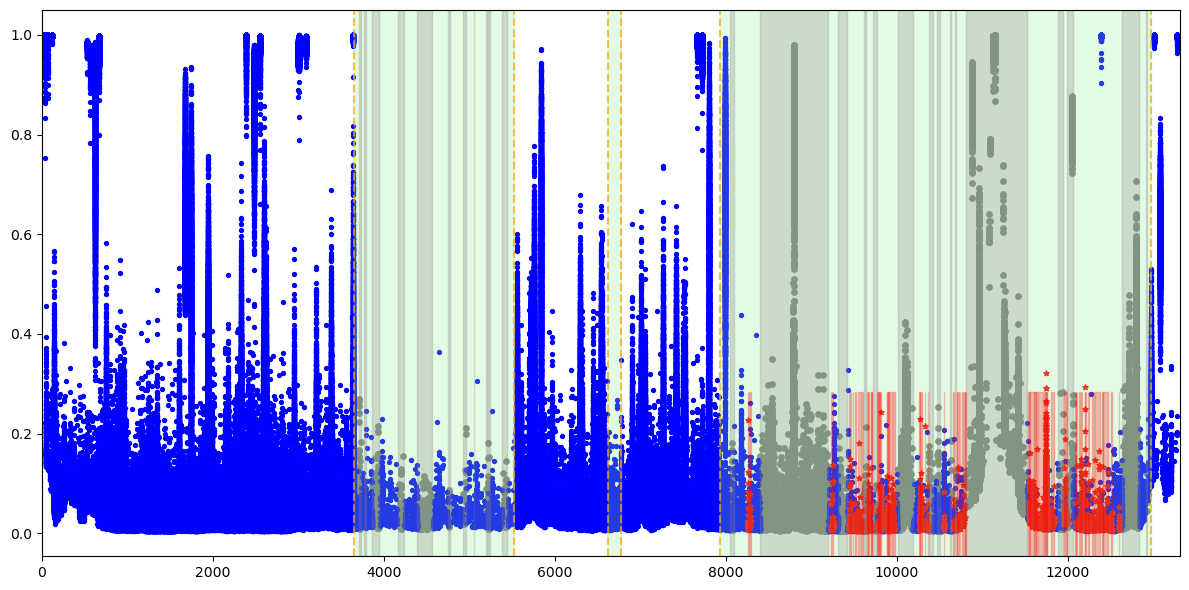

In [49]:
# Same plot as above but no labels
plt.figure(figsize=(12, 6))
# Plot grey points, blue points, and red stars
plt.scatter(grey_x, grey_y, s=15, color='Gray', label='Expansion Segments')
plt.scatter(blue_x, blue_y, s=8, color='Blue', label='Remaining Points')
plt.scatter(red_x, red_y, s=15, color='Red', marker='*', label='Conserved Segments')
plt.scatter(white_x, white_y, s=8, color='white', alpha=0)

# Add vertical lines and shaded regions
for start, end in rRNA_positions:
    plt.axvline(x=start, color='orange', linestyle='--', alpha=0.7)
    plt.axvline(x=end, color='orange', linestyle='--', alpha=0.7)
    plt.axvspan(start, end, alpha=0.25, color='lightgreen')

for start, end in expansion_positions2:
    plt.axvspan(start, end, alpha=0.25, color='grey')

for start, end in expansion_positions1:
    plt.axvspan(start, end, alpha=0.25, color='grey')

for start, end in csvd_pos:
    plt.axvspan(start, end, 0, 0.3, alpha=0.25, color='red')

plt.xlim(0, 13314)
plt.tight_layout()
plt.savefig("og_vcf_nolabels.pdf", format="pdf", bbox_inches="tight")


In [50]:
# Modified here: New VCF Parser for modified og vcfs
def read_vcf2(path):
    with open(path, 'r') as f:
        lines = [l for l in f if not l.startswith('##')]

    df = pd.read_csv(
        io.StringIO(''.join(lines)),
        dtype={'#CHROM': str, 'POS': int, 'ID': str, 'REF': str, 'ALT': str,
                'QUAL': str, 'FILTER': str, 'AF': float, 'estimated_copy_number': float, 'normalized_AF': float},
        sep='\t'
    ).rename(columns={'#CHROM': 'CHROM'})

    return df

grey_x, grey_y, blue_x, blue_y, red_x, red_y, white_x, white_y = [], [], [], [], [], [], [], []

vcf_files = [os.path.join(modified_og_vcf_directory, file) for file in os.listdir(modified_og_vcf_directory) if file.startswith('E') and file not in skipped_files]

In [ ]:
#plotting original vcf (in new formatting w normalized AF) - similar to above code block

plt.figure(figsize=(12, 6))
for file in vcf_files:
    individual_df = read_vcf2(file)
    hold, xhold, rh, ah = read_txt3(individual_df, y_axis='normalized_AF') # Modified here: to include y_axis param for the respective use case

    grey_x_temp, grey_y_temp = [], []
    blue_x_temp, blue_y_temp = [], []
    red_x_temp, red_y_temp = [], []
    white_x_temp, white_y_temp = [], []

    # Modified here: Include 'Ref' and 'Alt' in data DataFrame
    data = pd.DataFrame({'x': xhold, 'y': hold, 'Ref': rh, 'Alt': ah})

    # Processing 28S segments
    for _, segment in df1.iterrows():
        start, end = segment['Start'], segment['End']
        mask = (data['x'] >= start) & (data['x'] <= end)
        selected_data = data[mask]
        grey_x_temp.extend(selected_data['x'].tolist())
        grey_y_temp.extend(selected_data['y'].tolist())
        data = data[~mask]

    # Processing 18S segments
    for _, segment in df2.iterrows():
        start, end = segment['Start'], segment['End']
        mask2 = (data['x'] >= start) & (data['x'] <= end)
        selected_data2 = data[mask2]
        grey_x_temp.extend(selected_data2['x'].tolist())
        grey_y_temp.extend(selected_data2['y'].tolist())
        data = data[~mask2]

    # Processing homopolymer segments
    for _, segment in df3.iterrows():
        start, end = segment['Start'], segment['End']
        mask3 = (data['x'] >= start) & (data['x'] <= end)
        selected_data3 = data[mask3]
        white_x_temp.extend(selected_data3['x'].tolist())
        white_y_temp.extend(selected_data3['y'].tolist())
        data = data[~mask3]

    # Processing conserved segments
    for _, segment in df4.iterrows():
        start, end = segment['Start'], segment['End']
        mask4 = (data['x'] >= start) & (data['x'] <= end)
        selected_data4 = data[mask4]
        red_x_temp.extend(selected_data4['x'].tolist())
        red_y_temp.extend(selected_data4['y'].tolist())
        data = data[~mask4]

    # Modified here: Processing pseudogene segments with Ref and Alt matching
    for _, segment in df5.iterrows():
        start, end = segment['Start'], segment['End']
        ref_seg = segment['Ref']
        alt_seg = segment['Alt']
        mask5 = (
            (data['x'] >= start) &
            (data['x'] <= end) &
            (data['Ref'] == ref_seg) &
            (data['Alt'] == alt_seg)
        )
        selected_data5 = data[mask5]
        white_x_temp.extend(selected_data5['x'].tolist())
        white_y_temp.extend(selected_data5['y'].tolist())
        data = data[~mask5]

    # Remaining points are blue points
    blue_x_temp.extend(data['x'].tolist())
    blue_y_temp.extend(data['y'].tolist())

    # Append to main lists
    grey_x.extend(grey_x_temp)
    grey_y.extend(grey_y_temp)
    blue_x.extend(blue_x_temp)
    blue_y.extend(blue_y_temp)
    red_x.extend(red_x_temp)
    red_y.extend(red_y_temp)
    white_x.extend(white_x_temp)
    white_y.extend(white_y_temp)

# Plot grey, blue, red, and white points
plt.scatter(grey_x, grey_y, s=15, color='Gray', label='Expansion Segments')
plt.scatter(blue_x, blue_y, s=8, color='Blue', label='Remaining Points')
plt.scatter(red_x, red_y, s=15, color='Red', marker='*', label='Conserved Segments')
plt.scatter(white_x, white_y, s=8, color='white', alpha=0)

# Add vertical lines and shaded regions
for start, end in rRNA_positions:
    plt.axvline(x=start, color='orange', linestyle='--', alpha=0.7)
    plt.axvline(x=end, color='orange', linestyle='--', alpha=0.7)
    plt.axvspan(start, end, alpha=0.25, color='lightgreen')

for start, end in expansion_positions2:
    plt.axvspan(start, end, alpha=0.25, color='grey')

for start, end in expansion_positions1:
    plt.axvspan(start, end, alpha=0.25, color='grey')

for start, end in csvd_pos:
    plt.axvspan(start, end, 0, 0.3, alpha=0.25, color='red')

plt.xlabel('Position')
plt.ylabel('Absolute count of variants')
plt.xlim(0, 13314)
plt.legend()
plt.tight_layout()
plt.savefig("og_vcf_normalized.pdf", format="pdf", bbox_inches="tight")
# plt.show()

In [ ]:
# Same plot as above but no labels
plt.figure(figsize=(12, 6))
# Plot grey, blue, red, and white points
plt.scatter(grey_x, grey_y, s=15, color='Gray', label='Expansion Segments')
plt.scatter(blue_x, blue_y, s=8, color='Blue', label='Remaining Points')
plt.scatter(red_x, red_y, s=15, color='Red', marker='*', label='Conserved Segments')
plt.scatter(white_x, white_y, s=8, color='white', alpha=0)

# Add vertical lines and shaded regions
for start, end in rRNA_positions:
    plt.axvline(x=start, color='orange', linestyle='--', alpha=0.7)
    plt.axvline(x=end, color='orange', linestyle='--', alpha=0.7)
    plt.axvspan(start, end, alpha=0.25, color='lightgreen')

for start, end in expansion_positions2:
    plt.axvspan(start, end, alpha=0.25, color='grey')

for start, end in expansion_positions1:
    plt.axvspan(start, end, alpha=0.25, color='grey')

for start, end in csvd_pos:
    plt.axvspan(start, end, 0, 0.3, alpha=0.25, color='red')

plt.xlim(0, 13314)
plt.tight_layout()
plt.savefig("og_vcf_normalized_nolabels.pdf", format="pdf", bbox_inches="tight")

/var/folders/hb/l21bg8lx3tgc5ky3s56cwdth0000gn/T/ipykernel_52943/1175697658.py:23: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()


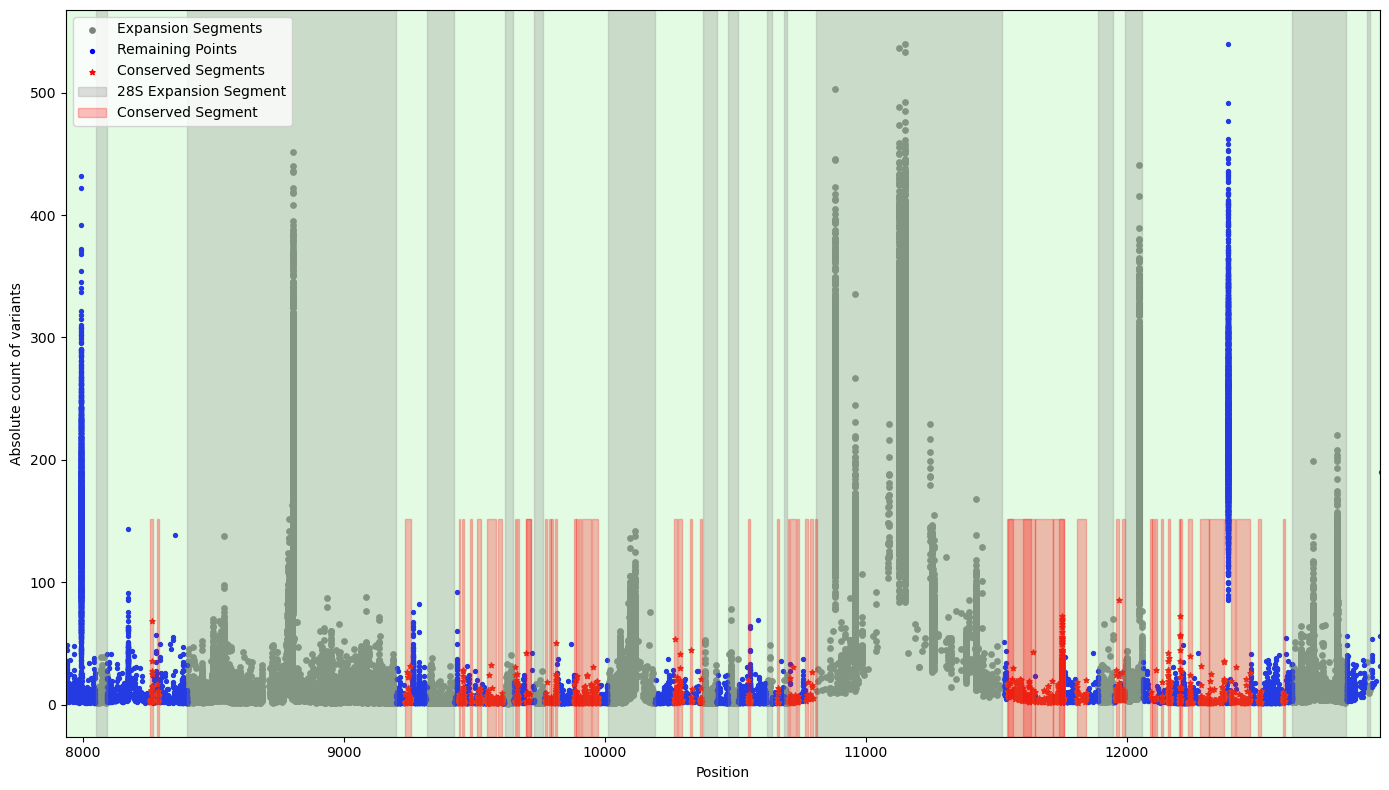

In [ ]:
plt.figure(figsize=(14, 8))

plt.scatter(grey_x, grey_y, s=15, color='Gray', label='Expansion Segments')
plt.scatter(blue_x, blue_y, s=8, color='Blue', label='Remaining Points')
plt.scatter(red_x, red_y, s=15, color='Red', marker='*', label='Conserved Segments')

for start, end in rRNA_positions:
    plt.axvspan(start, end, alpha=0.25, color='lightgreen')

for start, end in expansion_positions1:
    plt.axvspan(start, end, alpha=0.25, color='grey', label='28S Expansion Segment')

for start, end in csvd_pos:
    plt.axvspan(start, end, 0, 0.3, alpha=0.25, color='red', label='Conserved Segment')

handles, labels = plt.gca().get_legend_handles_labels()
by_label = dict(zip(labels, handles))
plt.legend(by_label.values(), by_label.keys())

plt.xlabel('Position')
plt.ylabel('Absolute count of variants')
plt.xlim(7935, 12969)  # Zoom in on the 28S region
plt.tight_layout()
plt.savefig("og_vcf_normalized_28S.pdf", format="pdf", bbox_inches="tight")
# plt.show()


In [ ]:
# Same plot as above but no labels
plt.figure(figsize=(14, 8))

plt.scatter(grey_x, grey_y, s=15, color='Gray', label='Expansion Segments')
plt.scatter(blue_x, blue_y, s=8, color='Blue', label='Remaining Points')
plt.scatter(red_x, red_y, s=15, color='Red', marker='*', label='Conserved Segments')

for start, end in rRNA_positions:
    plt.axvspan(start, end, alpha=0.25, color='lightgreen')

for start, end in expansion_positions1:
    plt.axvspan(start, end, alpha=0.25, color='grey', label='28S Expansion Segment')

for start, end in csvd_pos:
    plt.axvspan(start, end, 0, 0.3, alpha=0.25, color='red', label='Conserved Segment')

plt.xlim(7935, 12969) 
plt.tight_layout()
plt.savefig("og_vcf_normalized_28S_nolabels.pdf", format="pdf", bbox_inches="tight")

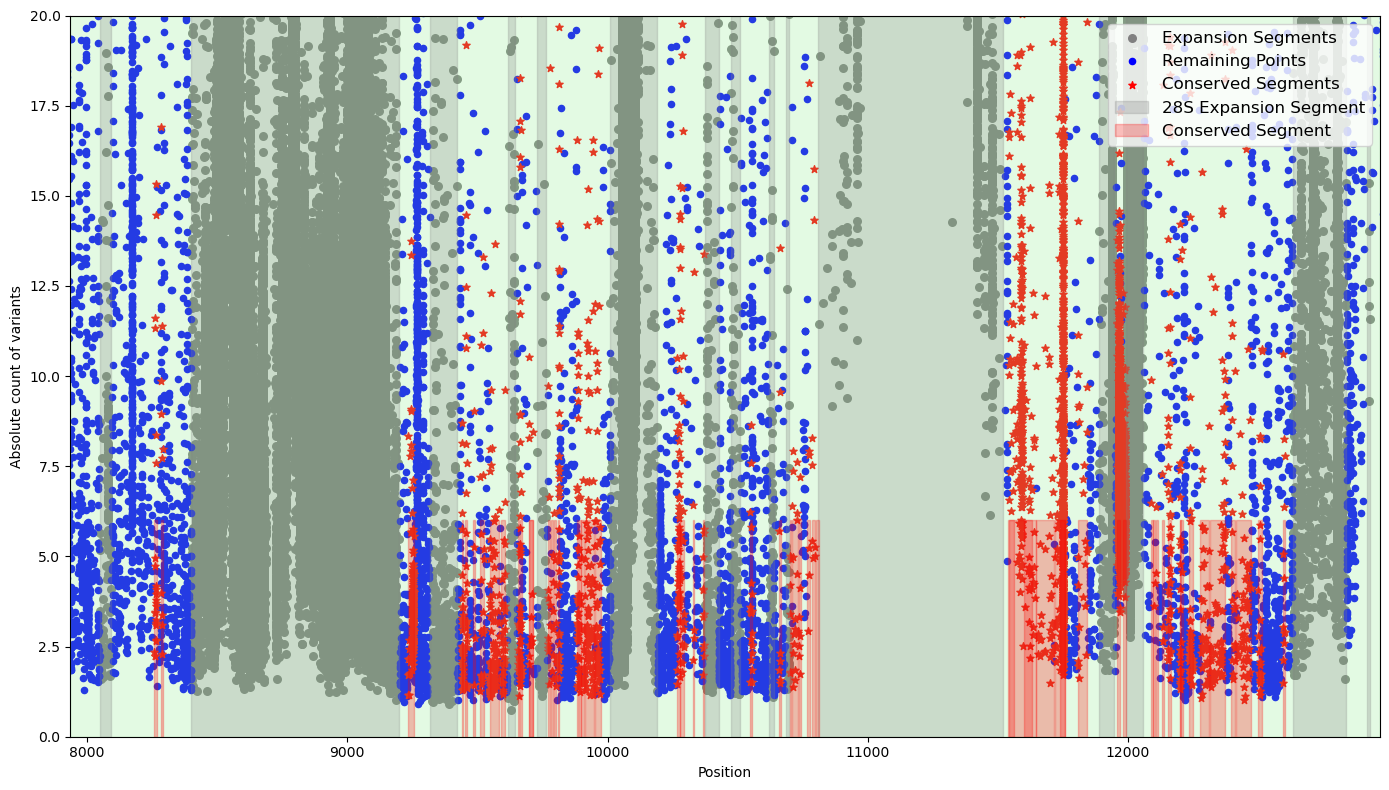

In [34]:
plt.figure(figsize=(14, 8))  

plt.scatter(grey_x, grey_y, s=30, color='Gray', label='Expansion Segments')
plt.scatter(blue_x, blue_y, s=20, color='Blue', label='Remaining Points')
plt.scatter(red_x, red_y, s=30, color='Red', marker='*', label='Conserved Segments')

for start, end in rRNA_positions:
    plt.axvspan(start, end, alpha=0.25, color='lightgreen')

for start, end in expansion_positions1:
    plt.axvspan(start, end, alpha=0.25, color='grey', label='28S Expansion Segment')

for start, end in csvd_pos:
    plt.axvspan(start, end, 0, 0.3, alpha=0.25, color='red', label='Conserved Segment')

handles, labels = plt.gca().get_legend_handles_labels()
by_label = dict(zip(labels, handles))
plt.legend(by_label.values(), by_label.keys(), loc='upper right', fontsize='large')

plt.xlabel('Position')
plt.ylabel('Absolute count of variants')
plt.xlim(7935, 12969)  # Focus on the 28S region
plt.ylim(0, 20)       # Limit y-axis to 20/100 for a zoomed-in view
plt.tight_layout()
plt.show()


In [11]:
start_28S, end_28S = 7935, 12969

expansion_segments = expansion_positions1
conserved_segments = csvd_pos  

# Modified here: Define set for pseudogene variants with position, ref, alt
pg_variants = set()
for _, row in df5.iterrows():
    start = row['Start']
    end = row['End']
    ref = row['Ref']
    alt = row['Alt']
    for pos in range(start, end + 1):
        pg_variants.add((pos, ref, alt))

hmplr_positions = set()
for _, row in df3.iterrows():
    start = row['Start']
    end = row['End']
    hmplr_positions.update(range(start, end + 1))

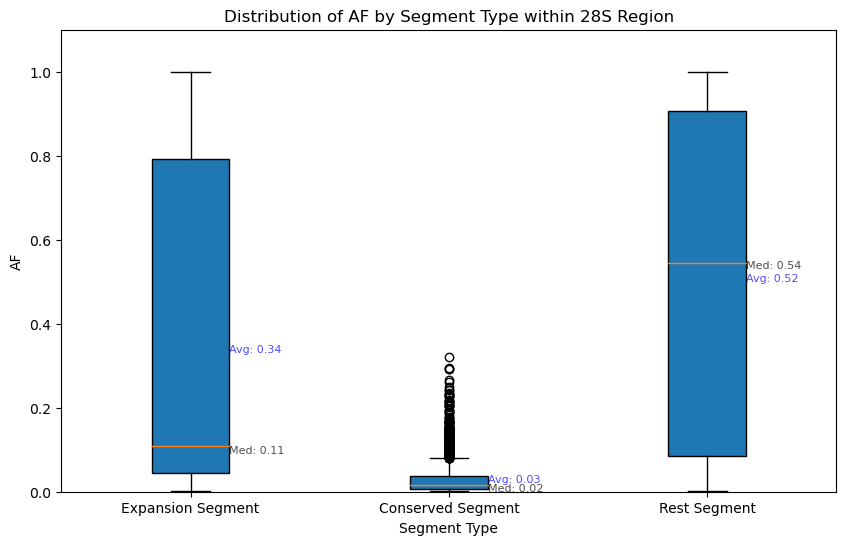

In [12]:
# validating Jon's AF boxplots of 28S (not unique) - modified og vcf files but using AF column

expansion_AF = []
conserved_AF = []
rest_AF = []

for file_path in vcf_files:
    df = read_vcf2(file_path)
    
    # Filter for positions within the 28S region
    df = df[(df['POS'] >= start_28S) & (df['POS'] <= end_28S)]

    for _, row in df.iterrows():
        pos = row['POS']
        ref = row['REF']
        alt = row['ALT']
        af = row['AF'] 

        # Modified here: to exclude pg on pos-ref-alt key
        if (pos, ref, alt) in pg_variants:
            continue

        if pos in hmplr_positions:
            continue

        if any(start <= pos <= end for start, end in expansion_segments):
            expansion_AF.append(af)
        elif any(start <= pos <= end for start, end in conserved_segments):
            conserved_AF.append(af)
        else:
            rest_AF.append(af)

data = [expansion_AF, conserved_AF, rest_AF]
labels = ['Expansion Segment', 'Conserved Segment', 'Rest Segment']

plt.figure(figsize=(10, 6))
box = plt.boxplot(data, labels=labels, patch_artist=True)

for i, afs in enumerate(data):
    if afs:  
        median = round(np.median(afs), 2)
        average = round(np.mean(afs), 2)
        
        if median > average:
            plt.text(i + 1.15, median, f'Med: {median}', ha='left', va='center', 
                     fontsize=8, color='black', alpha=0.7)
            plt.text(i + 1.15, average, f'Avg: {average}', ha='left', va='top', 
                     fontsize=8, color='blue', alpha=0.7)
        else:
            plt.text(i + 1.15, median, f'Med: {median}', ha='left', va='top', 
                     fontsize=8, color='black', alpha=0.7)
            plt.text(i + 1.15, average, f'Avg: {average}', ha='left', va='center', 
                     fontsize=8, color='blue', alpha=0.7)


plt.title("Distribution of AF by Segment Type within 28S Region")
plt.ylabel("AF")
plt.xlabel("Segment Type")

plt.ylim(0, max(max(afs) for afs in data if afs) * 1.1)
plt.savefig("AF_boxplot_28S.svg", format="svg", bbox_inches="tight")

# plt.show()

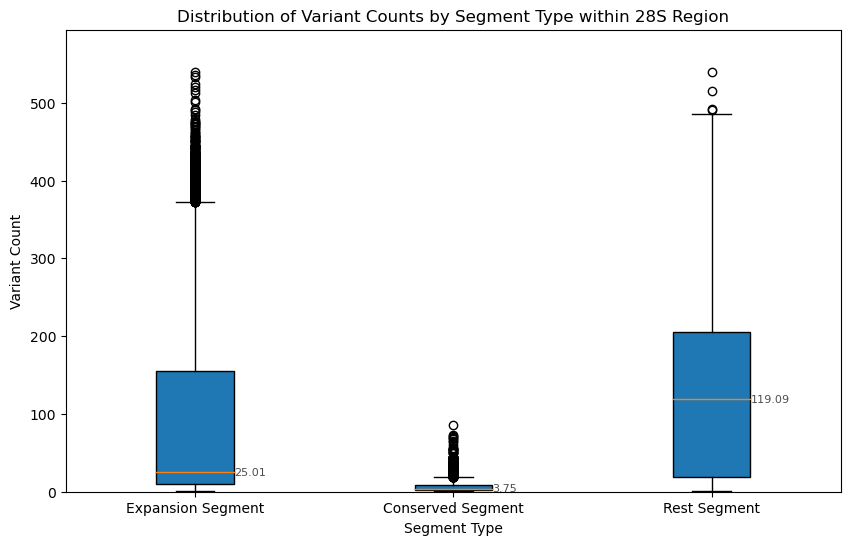

In [13]:
# similar to above plot but for modified og vcf files - normalized AF
expansion_variant_counts = []
conserved_variant_counts = []
rest_variant_counts = []

for file_path in vcf_files:
    df = read_vcf2(file_path)
    
    # Filter for positions within the 28S region
    df = df[(df['POS'] >= start_28S) & (df['POS'] <= end_28S)]

    for _, row in df.iterrows():
        pos = row['POS']
        ref = row['REF']
        alt = row['ALT']

        # Modified here: to exclude pg on pos-ref-alt key
        if (pos, ref, alt) in pg_variants:
            continue

        # Skip homopolymer positions
        if pos in hmplr_positions:
            continue

        # Append the normalized_AF to the appropriate list based on segment type
        if any(start <= pos <= end for start, end in expansion_segments):
            expansion_variant_counts.append(row['normalized_AF'])
        elif any(start <= pos <= end for start, end in conserved_segments):
            conserved_variant_counts.append(row['normalized_AF'])
        else:
            rest_variant_counts.append(row['normalized_AF'])

data = [expansion_variant_counts, conserved_variant_counts, rest_variant_counts]
labels = ['Expansion Segment', 'Conserved Segment', 'Rest Segment']

plt.figure(figsize=(10, 6))
box = plt.boxplot(data, labels=labels, patch_artist=True)

for i, counts in enumerate(data):
    median = round(np.median(counts), 2)
    plt.text(i + 1.15, median, f'{median}', ha='left', va='center', 
                fontsize=8, color='black', alpha=0.7)

plt.title("Distribution of Variant Counts by Segment Type within 28S Region")
plt.ylabel("Variant Count")
plt.xlabel("Segment Type")

plt.ylim(0, max(max(counts) for counts in data if counts) * 1.1)
plt.savefig("VariantCounts_boxplot_28S.svg", format="svg", bbox_inches="tight")

# plt.show()


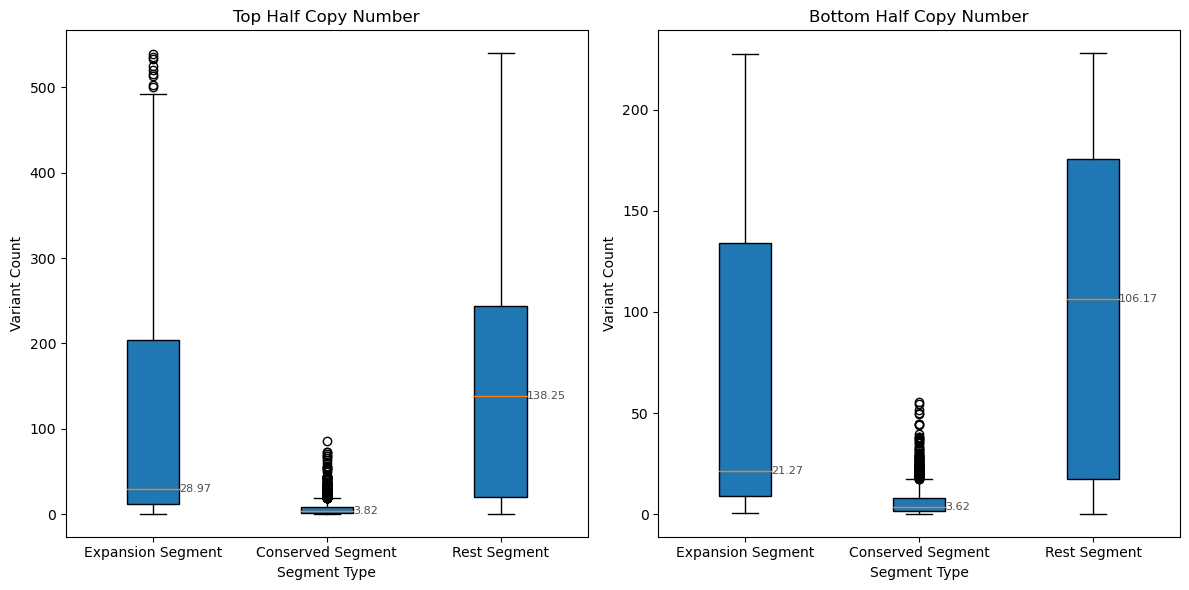

In [14]:
#stratify above plot by top half vs bottom half of estimated copy numbers - modified og vcf files (normalized AF

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

population_file = "/Users/fionachow/Documents/NYU/CDS/Summer 2024/Human rDNA Research/Project/Human-rDNA/outputs/others/1000data - Filtered Pop.csv"
pop_data = pd.read_csv(population_file)

# Extract relevant columns and calculate the median copy number
pop_data = pop_data[['Run', 'Estimated Copy #']].rename(columns={'Run': 'run', 'Estimated Copy #': 'estimated_copy_number'})
median_copy_number = pop_data['estimated_copy_number'].median()

# Separate runs into top and bottom half based on copy number
top_half_runs = set(pop_data[pop_data['estimated_copy_number'] > median_copy_number]['run'])
bottom_half_runs = set(pop_data[pop_data['estimated_copy_number'] <= median_copy_number]['run'])

# Grouped variant counts
top_expansion_variant_counts = []
top_conserved_variant_counts = []
top_rest_variant_counts = []

bottom_expansion_variant_counts = []
bottom_conserved_variant_counts = []
bottom_rest_variant_counts = []

for file_path in vcf_files:

    df = read_vcf2(file_path)
    df = df[(df['POS'] >= start_28S) & (df['POS'] <= end_28S)]
    run_id = file_path.split("/")[-1].split("_")[0]
    
    for _, row in df.iterrows():
        pos = row['POS']
        ref = row['REF']
        alt = row['ALT']
        
        if (pos, ref, alt) in pg_variants or pos in hmplr_positions:
            continue

        normalized_af = row['normalized_AF']

        if run_id in top_half_runs:
            if any(start <= pos <= end for start, end in expansion_segments):
                top_expansion_variant_counts.append(normalized_af)
            elif any(start <= pos <= end for start, end in conserved_segments):
                top_conserved_variant_counts.append(normalized_af)
            else:
                top_rest_variant_counts.append(normalized_af)
        elif run_id in bottom_half_runs:
            if any(start <= pos <= end for start, end in expansion_segments):
                bottom_expansion_variant_counts.append(normalized_af)
            elif any(start <= pos <= end for start, end in conserved_segments):
                bottom_conserved_variant_counts.append(normalized_af)
            else:
                bottom_rest_variant_counts.append(normalized_af)

top_data = [top_expansion_variant_counts, top_conserved_variant_counts, top_rest_variant_counts]
bottom_data = [bottom_expansion_variant_counts, bottom_conserved_variant_counts, bottom_rest_variant_counts]
labels = ['Expansion Segment', 'Conserved Segment', 'Rest Segment']

# Plot for top half of population
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
top_box = plt.boxplot(top_data, labels=labels, patch_artist=True)
for i, counts in enumerate(top_data):
    if counts:
        median = round(np.median(counts), 2)
        plt.text(i + 1.15, median, f'{median}', ha='left', va='center', fontsize=8, color='black', alpha=0.7)
plt.title("Top Half Copy Number")
plt.ylabel("Variant Count")
plt.xlabel("Segment Type")

# Plot for bottom half of population
plt.subplot(1, 2, 2)
bottom_box = plt.boxplot(bottom_data, labels=labels, patch_artist=True)
for i, counts in enumerate(bottom_data):
    if counts:
        median = round(np.median(counts), 2)
        plt.text(i + 1.15, median, f'{median}', ha='left', va='center', fontsize=8, color='black', alpha=0.7)
plt.title("Bottom Half Copy Number")
plt.ylabel("Variant Count")
plt.xlabel("Segment Type")

plt.tight_layout()
plt.show()

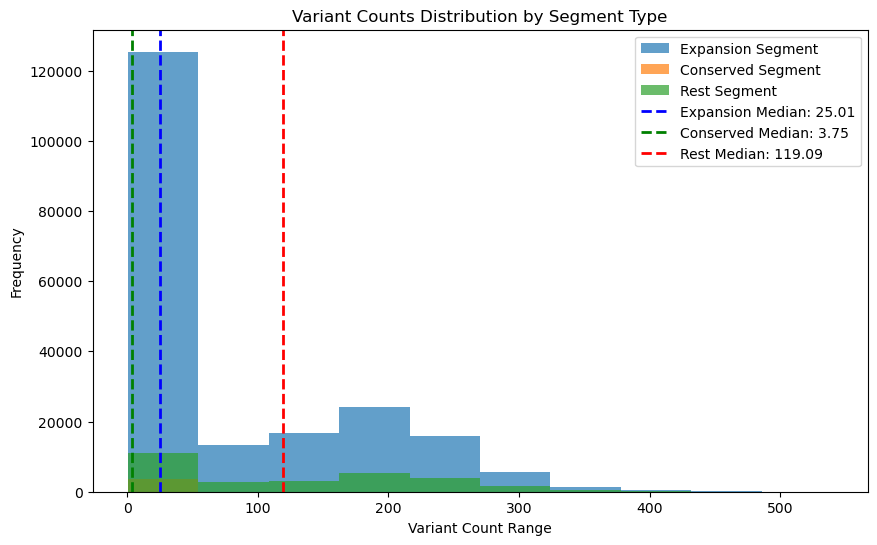

In [15]:
# Plot of Variant Counts Distribution by Segment Type - modified og vcf files (normalized AF)
expansion_variant_counts = []
conserved_variant_counts = []
rest_variant_counts = []

for file_path in vcf_files:
    df = read_vcf2(file_path)

    # Filter for positions within the 28S region
    df = df[(df['POS'] >= start_28S) & (df['POS'] <= end_28S)]

    for _, row in df.iterrows():
        pos = row['POS']
        ref = row['REF']
        alt = row['ALT']

        # Modified here: to exclude pg on pos-ref-alt key
        if (pos, ref, alt) in pg_variants:
            continue

        # Skip homopolymer positions
        if pos in hmplr_positions:
            continue
        
        # Append the normalized_AF to the appropriate list based on segment type
        if any(start <= pos <= end for start, end in expansion_segments):
            expansion_variant_counts.append(row['normalized_AF'])
        elif any(start <= pos <= end for start, end in conserved_segments):
            conserved_variant_counts.append(row['normalized_AF'])
        else:
            rest_variant_counts.append(row['normalized_AF'])

all_counts = expansion_variant_counts + conserved_variant_counts + rest_variant_counts
num_bins = 10 
hist, bin_edges = np.histogram(all_counts, bins=num_bins)

expansion_median = np.median(expansion_variant_counts)
conserved_median = np.median(conserved_variant_counts)
rest_median = np.median(rest_variant_counts)

fig, ax = plt.subplots(figsize=(10, 6))

ax.hist(expansion_variant_counts, bins=bin_edges, alpha=0.7, label='Expansion Segment')
ax.hist(conserved_variant_counts, bins=bin_edges, alpha=0.7, label='Conserved Segment')
ax.hist(rest_variant_counts, bins=bin_edges, alpha=0.7, label='Rest Segment')

ax.axvline(expansion_median, color='blue', linestyle='dashed', linewidth=2, label=f'Expansion Median: {expansion_median:.2f}')
ax.axvline(conserved_median, color='green', linestyle='dashed', linewidth=2, label=f'Conserved Median: {conserved_median:.2f}')
ax.axvline(rest_median, color='red', linestyle='dashed', linewidth=2, label=f'Rest Median: {rest_median:.2f}')

ax.set_title("Variant Counts Distribution by Segment Type")
ax.set_xlabel("Variant Count Range")
ax.set_ylabel("Frequency")
ax.legend()

plt.show()

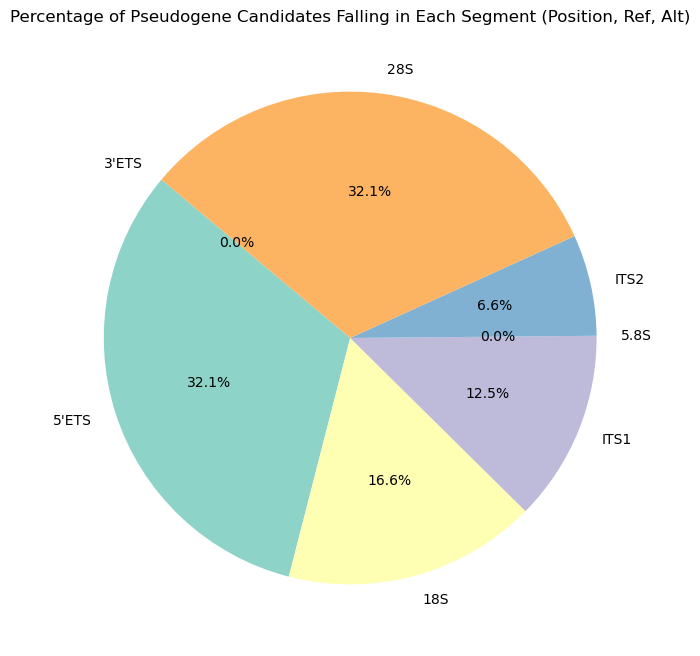

In [16]:
# Plot of Percentage of Pseudogene Candidates Falling in Each Segment (Position, Ref, Alt)
all_positions = [
    [1, 3656, "5'ETS"],
    [3657, 5527, '18S'],
    [5528, 6622, 'ITS1'],
    [6623, 6779, '5.8S'],
    [6780, 7934, 'ITS2'],
    [7935, 12969, '28S'],
    [12970, 13314, "3'ETS"]
]

segment_counts = {label: 0 for _, _, label in all_positions}

# Modified here: to pg on pos-ref-alt key
for pos, ref, alt in pg_variants:
    for start, end, label in all_positions:
        if start <= pos <= end:
            segment_counts[label] += 1
            break  # Stop after finding the matching segment

# Calculate the total number of pg_positions
total_pg_positions = sum(segment_counts.values())

# Calculate percentages for each segment if there are pseudogene positions
if total_pg_positions > 0:
    segment_percentages = {label: (count / total_pg_positions) * 100 for label, count in segment_counts.items()}
else:
    segment_percentages = {label: 0 for label in segment_counts}  # If no pg_positions, set percentages to 0

labels = list(segment_percentages.keys())
sizes = list(segment_percentages.values())

plt.figure(figsize=(8, 8))
plt.pie(sizes, labels=labels, autopct='%1.1f%%', startangle=140, colors=sns.color_palette("Set3", len(labels)))
plt.title('Percentage of Pseudogene Candidates Falling in Each Segment (Position, Ref, Alt)')
plt.savefig("pg_segment_distribution.svg", format="svg", bbox_inches="tight")
# plt.show()


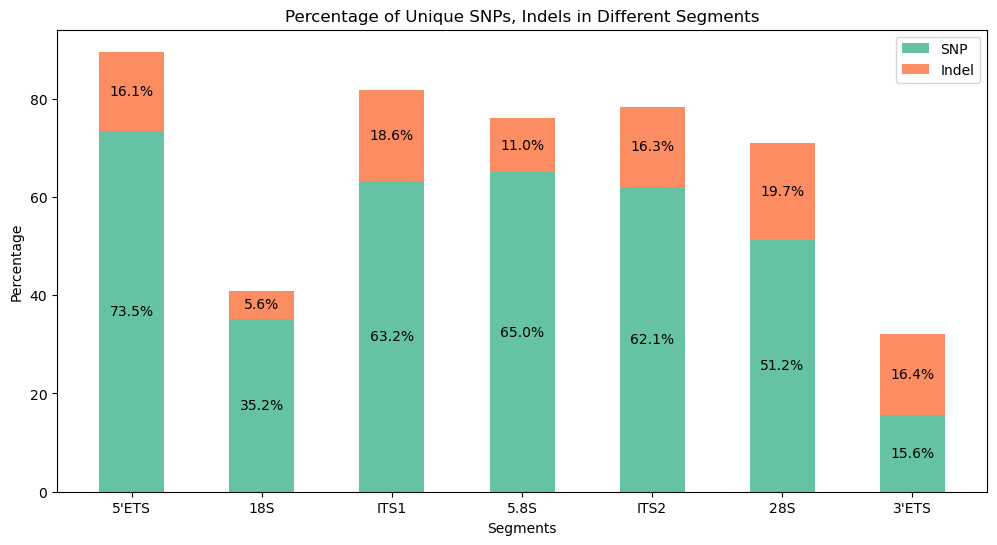

Overall SNP Percentage: 58.40%
Overall Indel Percentage: 16.42%
Overall No Change Percentage: 25.18%


In [26]:
# Plot for Percentage of Unique SNPs, Indels in Different Segments - og vcf

og_vcf_directory = '/Users/fionachow/Documents/NYU/CDS/Summer 2024/Human rDNA Research/Project/Human-rDNA/original reference/original_vcf_all/'
modified_og_vcf_directory = '/Users/fionachow/Documents/NYU/CDS/Summer 2024/Human rDNA Research/Project/Human-rDNA/outputs/src_outputs/modified_original_reference'

skipped_files_path = os.path.join(modified_og_vcf_directory, 'skipped_files.csv')

if os.path.exists(skipped_files_path):
    skipped_files_df = pd.read_csv(skipped_files_path)
    skipped_files = set(skipped_files_df['Run'].apply(lambda x: f"{x}_rDNA.vcf"))
else:
    skipped_files = set()

if os.path.isdir(og_vcf_directory):
    vcf_files = [os.path.join(og_vcf_directory, file) for file in os.listdir(og_vcf_directory) if file.startswith('E') and file not in skipped_files] # Modified here
else:
    raise ValueError(f"{og_vcf_directory} is not a valid directory")

# Initialize dictionaries to store counts of unique SNPs, indels, and no changes
position_data = {i: {'snp': set(), 'indel': set(), 'no_change': 0} for i in range(1, 13315)}

# Modified here: Set to keep track of positions with non-pseudogene variants across all files
positions_with_variants = set()

# Function to parse VCF files and classify SNPs and indels
def parse_vcf(file):
    vcf_df = pd.read_csv(file, comment='#', delimiter='\t', header=None,
                         names=['CHROM', 'POS', 'ID', 'REF', 'ALT', 'QUAL', 'FILTER', 'INFO'])
    for _, row in vcf_df.iterrows():
        pos = row['POS']
        ref = row['REF']
        alt = row['ALT']

        # Modified here: to exclude pg on pos-ref-alt key
        if (pos, ref, alt) in pg_variants:
            continue
        # Exclude homopolymer positions
        if pos in hmplr_positions:
            continue
        if pos > 13314:
            print(f"Position {pos} in file {file} is outside the expected range.")
            continue
        # Classify as SNP or Indel
        if len(ref) == len(alt):
            variation = f"{ref}_{alt}"
            position_data[pos]['snp'].add(variation)
        else:
            variation = f"{ref}_{alt}"
            position_data[pos]['indel'].add(variation)
        
        # Modified here: Mark position as having a non-pseudogene variant
        positions_with_variants.add(pos)
        
### Modified here ###
for vcf_file in vcf_files:
    parse_vcf(vcf_file)  

# After processing all files, compute positions without non-pseudogene variants
all_positions_set = set(range(1, 13315))
positions_without_variants = all_positions_set - positions_with_variants - hmplr_positions # Modified here

# Update 'no_change' count for positions without variants
for pos in positions_without_variants:
    position_data[pos]['no_change'] = 1  # Positions with no variants across all samples
### Modification ends here ###

# Prepare data for each segment
segment_data = {label: {'snp': 0, 'indel': 0, 'no_change': 0} for _, _, label in all_positions}

# Count occurrences for each segment
for pos in range(1, 13315):
    for start, end, label in all_positions:
        if start <= pos <= end:
            segment_data[label]['snp'] += len(position_data[pos]['snp'])
            segment_data[label]['indel'] += len(position_data[pos]['indel'])
            segment_data[label]['no_change'] += position_data[pos]['no_change']
            break  # Position belongs to one segment only

# Calculate percentages for each segment
segment_percentages = {}
for label in segment_data:
    total_count = (segment_data[label]['snp'] + 
                   segment_data[label]['indel'] + 
                   segment_data[label]['no_change'])
    if total_count > 0:
        snp_percentage = (segment_data[label]['snp'] / total_count) * 100
        indel_percentage = (segment_data[label]['indel'] / total_count) * 100
        no_change_percentage = (segment_data[label]['no_change'] / total_count) * 100
    else:
        snp_percentage = indel_percentage = no_change_percentage = 0
    
    segment_percentages[label] = {
        'snp': snp_percentage,
        'indel': indel_percentage,
        'no_change': no_change_percentage
    }

# Prepare data for histogram
segments = list(segment_percentages.keys())
snp_percentages = [segment_percentages[seg]['snp'] for seg in segments]
indel_percentages = [segment_percentages[seg]['indel'] for seg in segments]

# Plotting the histogram (stacked bar chart)
bar_width = 0.5
x = np.arange(len(segments))

plt.figure(figsize=(12, 6))
colors = sns.color_palette("Set2", 2)

bars1 = plt.bar(x, snp_percentages, color=colors[0], width=bar_width, label='SNP')
bars2 = plt.bar(x, indel_percentages, bottom=snp_percentages, color=colors[1], width=bar_width, label='Indel')

plt.xlabel('Segments')
plt.ylabel('Percentage')
plt.title('Percentage of Unique SNPs, Indels in Different Segments')
plt.xticks(x, segments)
plt.legend()

def add_labels_stacked(bars):
    for bar in bars:
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width() / 2.0, bar.get_y() + height / 2,
                 f'{height:.1f}%', ha='center', va='center', color='black')

add_labels_stacked(bars1)
add_labels_stacked(bars2)
plt.tight_layout()
plt.savefig("unique_snp_indel_percentages.svg", format="svg", bbox_inches="tight")
# plt.show()

# Calculate overall percentages across the entire dataset
total_snp = sum(len(position_data[pos]['snp']) for pos in position_data)
total_indel = sum(len(position_data[pos]['indel']) for pos in position_data )
total_no_change = sum(position_data[pos].get('no_change', 0) for pos in position_data)
total_positions = total_snp + total_indel + total_no_change

# Avoid division by zero
if total_positions > 0:
    overall_snp_percentage = (total_snp / total_positions) * 100
    overall_indel_percentage = (total_indel / total_positions) * 100
    overall_no_change_percentage = (total_no_change / total_positions) * 100
else:
    overall_snp_percentage = overall_indel_percentage = overall_no_change_percentage = 0

# Print overall percentages
print(f"Overall SNP Percentage: {overall_snp_percentage:.2f}%")
print(f"Overall Indel Percentage: {overall_indel_percentage:.2f}%")
print(f"Overall No Change Percentage: {overall_no_change_percentage:.2f}%")


Biggest Indel Size: 28
Median Indel Size: 2.0


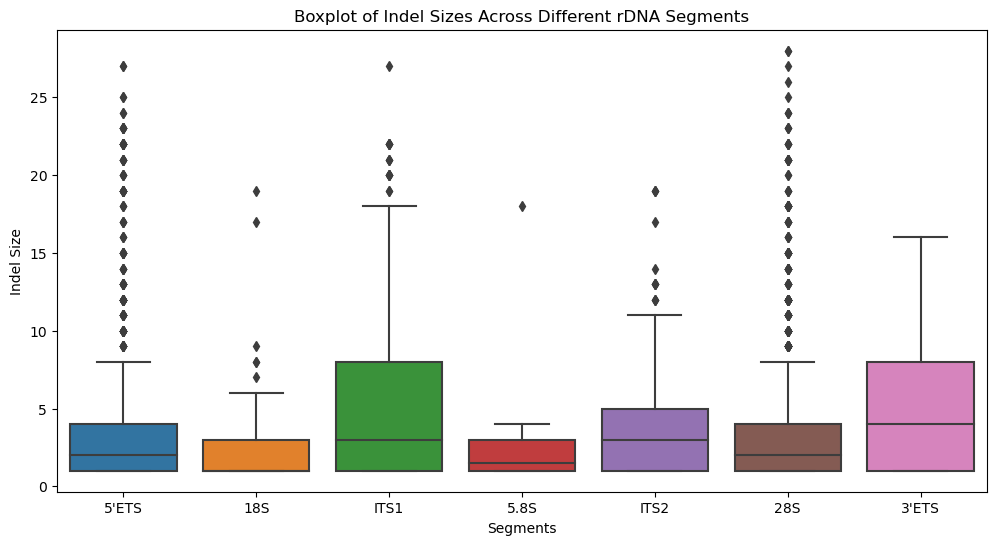

In [ ]:
# Plot for Boxplot of Indel Sizes Across Different rDNA Segments - og vcf
# Extract indel sizes and segment them
indel_sizes = {label: [] for _, _, label in all_positions}

for pos in range(1, 13315):
    for variation in position_data[pos]['indel']:
        ref, alt = variation.split('_')
        indel_size = abs(len(ref) - len(alt))
        for start, end, label in all_positions:
            if start <= pos <= end:
                indel_sizes[label].append(indel_size)

# Initialize variables to store the biggest indel size and all indel sizes
all_indel_sizes = []
max_indel_size = 0

# Process the indel sizes to find the max and collect all sizes for median calculation
for label in indel_sizes:
    for size in indel_sizes[label]:
        all_indel_sizes.append(size)
        if size > max_indel_size:
            max_indel_size = size

# Calculate the median indel size
median_indel_size = statistics.median(all_indel_sizes)

print(f"Biggest Indel Size: {max_indel_size}")
print(f"Median Indel Size: {median_indel_size}")

# Prepare data for boxplot
data = []
for label in indel_sizes:
    for size in indel_sizes[label]:
        data.append({'Segment': label, 'Indel Size': size})

indel_df = pd.DataFrame(data)

# Plotting the boxplot
plt.figure(figsize=(12, 6))
sns.boxplot(x='Segment', y='Indel Size', data=indel_df)
plt.xlabel('Segments')
plt.ylabel('Indel Size')
plt.title('Boxplot of Indel Sizes Across Different rDNA Segments')
plt.tight_layout()
plt.savefig("indel_size_boxplot.svg", format="svg", bbox_inches="tight")
# plt.show()

In [28]:
segment_data

saved_segment_data = segment_data

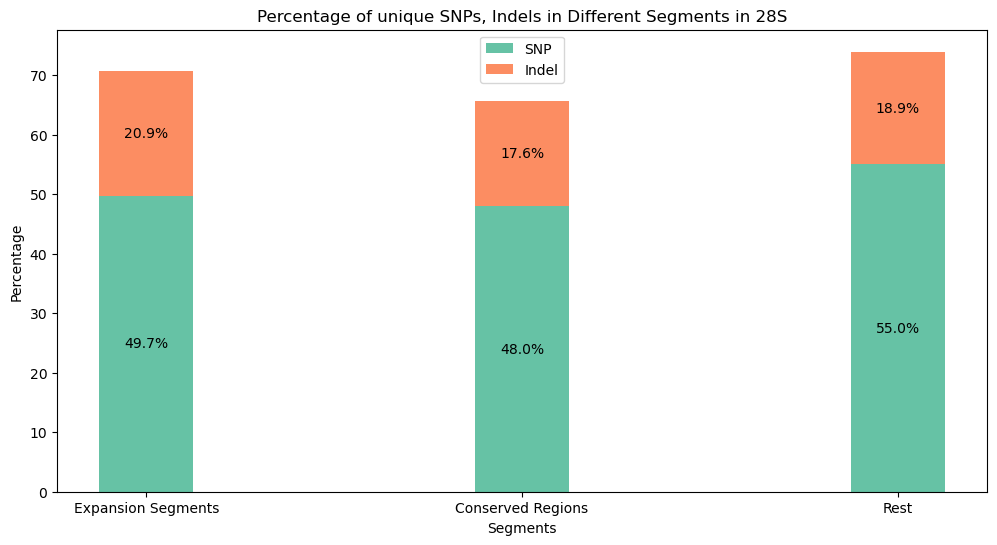

In [29]:
# Plot for Percentage of unique SNPs, Indels in Different Segments in 28S - og vcf
#28S only

exp_cor = []
exp_cor.extend(expansion_positions1)
exp_cor.extend(expansion_positions2)


# Prepare data for each segment category
segment_data = {
    'Expansion Segments': {'snp': 0, 'indel': 0, 'no_change': 0},
    'Conserved Regions': {'snp': 0, 'indel': 0, 'no_change': 0},
    'Rest': {'snp': 0, 'indel': 0, 'no_change': 0}
}

# Loop through each position in the range 7935,12970
for pos in range(7935, 12970): 
    counted = False
    
    # Check for expansion segments
    for start, end in exp_cor:
        if start <= pos <= end:
            segment_data['Expansion Segments']['snp'] += len(position_data[pos]['snp'])
            segment_data['Expansion Segments']['indel'] += len(position_data[pos]['indel'])
            segment_data['Expansion Segments']['no_change'] += position_data[pos]['no_change']
            counted = True  # Mark position as counted
            break
    
    # Check for conserved regions if not already counted
    if not counted:
        for start, end in csvd_pos:
            if start <= pos <= end:
                segment_data['Conserved Regions']['snp'] += len(position_data[pos]['snp'])
                segment_data['Conserved Regions']['indel'] += len(position_data[pos]['indel'])
                segment_data['Conserved Regions']['no_change'] += position_data[pos]['no_change']
                counted = True  
                break
    
    # Check for rest if not already counted
    if not counted:
        for start, end in rRNA_positions:
            if start <= pos <= end:
                segment_data['Rest']['snp'] += len(position_data[pos]['snp'])
                segment_data['Rest']['indel'] += len(position_data[pos]['indel'])
                segment_data['Rest']['no_change'] += position_data[pos]['no_change']
                counted = True  
                break

# Calculate percentages for each category
segment_percentages = {}
for label in segment_data:
    total_count = (segment_data[label]['snp'] + 
                   segment_data[label]['indel'] + 
                   segment_data[label]['no_change'])
    if total_count > 0:
        snp_percentage = (segment_data[label]['snp'] / total_count) * 100
        indel_percentage = (segment_data[label]['indel'] / total_count) * 100
        no_change_percentage = (segment_data[label]['no_change'] / total_count) * 100
    else:
        snp_percentage = indel_percentage = no_change_percentage = 0
    
    segment_percentages[label] = {
        'snp': snp_percentage,
        'indel': indel_percentage,
        'no_change': no_change_percentage
    }

# Prepare data for histogram
categories = list(segment_percentages.keys())
snp_percentages = [segment_percentages[cat]['snp'] for cat in categories]
indel_percentages = [segment_percentages[cat]['indel'] for cat in categories]
no_change_percentages = [segment_percentages[cat]['no_change'] for cat in categories]

# Plotting the histogram
bar_width = 0.25
x = range(len(categories))

plt.figure(figsize=(12, 6))

bars1 = plt.bar(x, snp_percentages, color=colors[0], width=bar_width, label='SNP')
bars2 = plt.bar(x, indel_percentages, bottom=snp_percentages, color=colors[1], width=bar_width, label='Indel')

plt.xlabel('Segments')
plt.ylabel('Percentage')
plt.title('Percentage of unique SNPs, Indels in Different Segments in 28S')
plt.xticks([p for p in x], categories)

plt.legend()

def add_labels_stacked(bars1, bars2):
    for bar1, bar2 in zip(bars1, bars2):
        height1 = bar1.get_height()
        height2 = bar2.get_height()
        plt.text(bar1.get_x() + bar1.get_width() / 2.0, height1 / 2, f'{height1:.1f}%', ha='center', va='center')
        plt.text(bar2.get_x() + bar2.get_width() / 2.0, height1 + height2 / 2, f'{height2:.1f}%', ha='center', va='center')

add_labels_stacked(bars1, bars2)
plt.tight_layout()
plt.savefig("snp_indel_percentages_28S.svg", format="svg", bbox_inches="tight")

# plt.show()


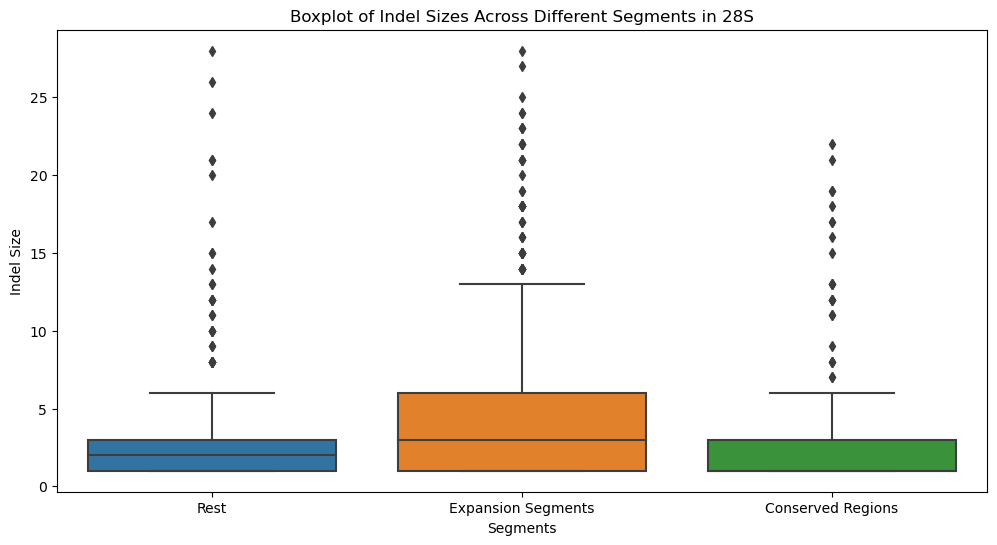

In [ ]:
# Plot for Boxplot of Indel Sizes Across Different Segments in 28S - og vcf
# Prepare data for boxplot
boxplot_data = []
for pos in range(7935, 12970):
    for variation in position_data[pos]['indel']:
        ref, alt = variation.split('_')
        indel_size = abs(len(ref) - len(alt))
        
        counted = False
        
        # Check for expansion segments
        for start, end in exp_cor:
            if start <= pos <= end:
                boxplot_data.append({'Segment': 'Expansion Segments', 'Indel Size': indel_size})
                counted = True
                break
        
        # Check for conserved regions if not already counted
        if not counted:
            for start, end in csvd_pos:
                if start <= pos <= end:
                    boxplot_data.append({'Segment': 'Conserved Regions', 'Indel Size': indel_size})
                    counted = True
                    break
        
        # Check for rest if not already counted
        if not counted:
            for start, end in rRNA_positions:
                if start <= pos <= end:
                    boxplot_data.append({'Segment': 'Rest', 'Indel Size': indel_size})
                    break

indel_df = pd.DataFrame(boxplot_data)

plt.figure(figsize=(12, 6))
sns.boxplot(x='Segment', y='Indel Size', data=indel_df)
plt.xlabel('Segments')
plt.ylabel('Indel Size')
plt.title('Boxplot of Indel Sizes Across Different Segments in 28S')
plt.tight_layout()
plt.savefig("indel_size_boxplot_28S.svg", format="svg", bbox_inches="tight")
# plt.show()

In [70]:
#3'ETS Analysis [12970, 13314]

## 1) Transitions vs Transversion 
## 2) No Change distribution of bases
### Purine: A, G
### Pyrimidines: T, C
### If point mutation is within the same group, then its a transition, else it is a transversion

# transitions = ['A_G', 'G_A', 'C_T', 'T_C']
# transversions = ['A_C', 'C_A', 'G_T', 'T_G']


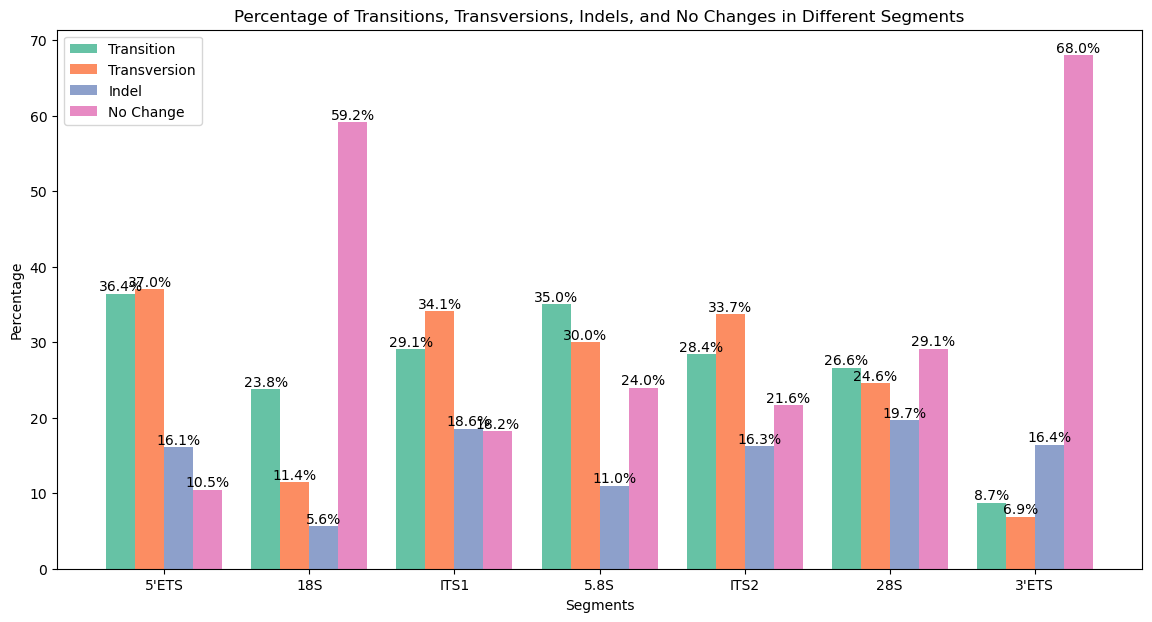

In [31]:
#Plot for Percentage of Transitions, Transversions, Indels, and No Changes in Different Segments - og vcf

# Initialize dictionaries to store counts of unique SNPs, indels, and no changes
position_data = {i: {'transition': set(), 'transversion': set(), 'indel': set(), 'no_change': 0} for i in range(1, 13315)}

# Modified here: Set to keep track of positions with non-pseudogene variants across all files
positions_with_variants = set()

# Define transitions and transversions
transitions = {'A_G', 'G_A', 'C_T', 'T_C'}
transversions = {'A_C', 'C_A', 'A_T', 'T_A', 'G_C', 'C_G', 'G_T', 'T_G'}

# Function to parse VCF files and classify SNPs and indels
def parse_vcf(file):
    vcf_df = pd.read_csv(file, comment='#', delimiter='\t', header=None,
                         names=['CHROM', 'POS', 'ID', 'REF', 'ALT', 'QUAL', 'FILTER', 'INFO'])
    for _, row in vcf_df.iterrows():
        pos = row['POS']
        ref = row['REF']
        alt = row['ALT']

        # Modified here: to exclude pg on pos-ref-alt key
        if (pos, ref, alt) in pg_variants:
            continue
        if pos in hmplr_positions:
            continue
        if pos > 13314:
            print(f"Position {pos} in file {file} is outside the expected range.")
        if len(ref) == len(alt):
            variation = f"{ref}_{alt}"
            if variation in transitions:
                position_data[pos]['transition'].add(variation)
            elif variation in transversions:
                position_data[pos]['transversion'].add(variation)
        else:
            variation = f"{ref}_{alt}"
            position_data[pos]['indel'].add(variation)
        
        # Modified here: Mark position as having a non-pseudogene variant
        positions_with_variants.add(pos)

### Modified Starts here (Similar to above above analysis logic for 'Plot for Percentage of Unique SNPs, Indels in Different Segments - og vcf')### 
for vcf_file in vcf_files:
    parse_vcf(vcf_file)  

# After processing all files, compute positions without non-pseudogene variants
all_positions_set = set(range(1, 13315))
positions_without_variants = all_positions_set - positions_with_variants - hmplr_positions # Modified here

# Update 'no_change' count for positions without variants
for pos in positions_without_variants:
    position_data[pos]['no_change'] = 1  # Positions with no variants across all samples
### Modification Ends here ###

# Prepare data for each segment
segment_data = {label: {'transition': 0, 'transversion': 0, 'indel': 0, 'no_change': 0} for _, _, label in all_positions}

# Count occurrences for each segment
for pos in range(1, 13315):
    for start, end, label in all_positions:
        if start <= pos <= end:
            segment_data[label]['transition'] += len(position_data[pos]['transition'])
            segment_data[label]['transversion'] += len(position_data[pos]['transversion'])
            segment_data[label]['indel'] += len(position_data[pos]['indel'])
            segment_data[label]['no_change'] += position_data[pos]['no_change']

# Calculate percentages for each segment
segment_percentages = {}
for label in segment_data:
    total_count = (segment_data[label]['transition'] + 
                   segment_data[label]['transversion'] + 
                   segment_data[label]['indel'] + 
                   segment_data[label]['no_change'])
    if total_count > 0:
        transition_percentage = (segment_data[label]['transition'] / total_count) * 100
        transversion_percentage = (segment_data[label]['transversion'] / total_count) * 100
        indel_percentage = (segment_data[label]['indel'] / total_count) * 100
        no_change_percentage = (segment_data[label]['no_change'] / total_count) * 100
    else:
        transition_percentage = transversion_percentage = indel_percentage = no_change_percentage = 0
    
    segment_percentages[label] = {
        'transition': transition_percentage,
        'transversion': transversion_percentage,
        'indel': indel_percentage,
        'no_change': no_change_percentage
    }

# Prepare data for histogram
segments = list(segment_percentages.keys())
transition_percentages = [segment_percentages[seg]['transition'] for seg in segments]
transversion_percentages = [segment_percentages[seg]['transversion'] for seg in segments]
indel_percentages = [segment_percentages[seg]['indel'] for seg in segments]
no_change_percentages = [segment_percentages[seg]['no_change'] for seg in segments]

# Plotting the histogram
bar_width = 0.2
x = range(len(segments))

plt.figure(figsize=(14, 7))

colors = sns.color_palette("Set2", 4)

bars1 = plt.bar(x, transition_percentages, color=colors[0], width=bar_width, label='Transition')
bars2 = plt.bar([p + bar_width for p in x], transversion_percentages, color=colors[1], width=bar_width, label='Transversion')
bars3 = plt.bar([p + bar_width * 2 for p in x], indel_percentages, color=colors[2], width=bar_width, label='Indel')
bars4 = plt.bar([p + bar_width * 3 for p in x], no_change_percentages, color=colors[3], width=bar_width, label='No Change')

plt.xlabel('Segments')
plt.ylabel('Percentage')
plt.title('Percentage of Transitions, Transversions, Indels, and No Changes in Different Segments')
plt.xticks([p + bar_width * 1.5 for p in x], segments)

plt.legend()

# Adding percentage labels
def add_labels(bars):
    for bar in bars:
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width() / 2.0, height, f'{height:.1f}%', ha='center', va='bottom')

add_labels(bars1)
add_labels(bars2)
add_labels(bars3)
add_labels(bars4)
plt.tight_layout()
plt.savefig("transition_transversion_indel_nochange_percentages.svg", format="svg", bbox_inches="tight")

# plt.show()

/var/folders/hb/l21bg8lx3tgc5ky3s56cwdth0000gn/T/ipykernel_52943/588001846.py:77: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  ax = sns.barplot(x='Segment', y='Percentage', hue='Variation', data=df[df['Variation'].isin(transition_vars)], palette='Set2', ci=None)


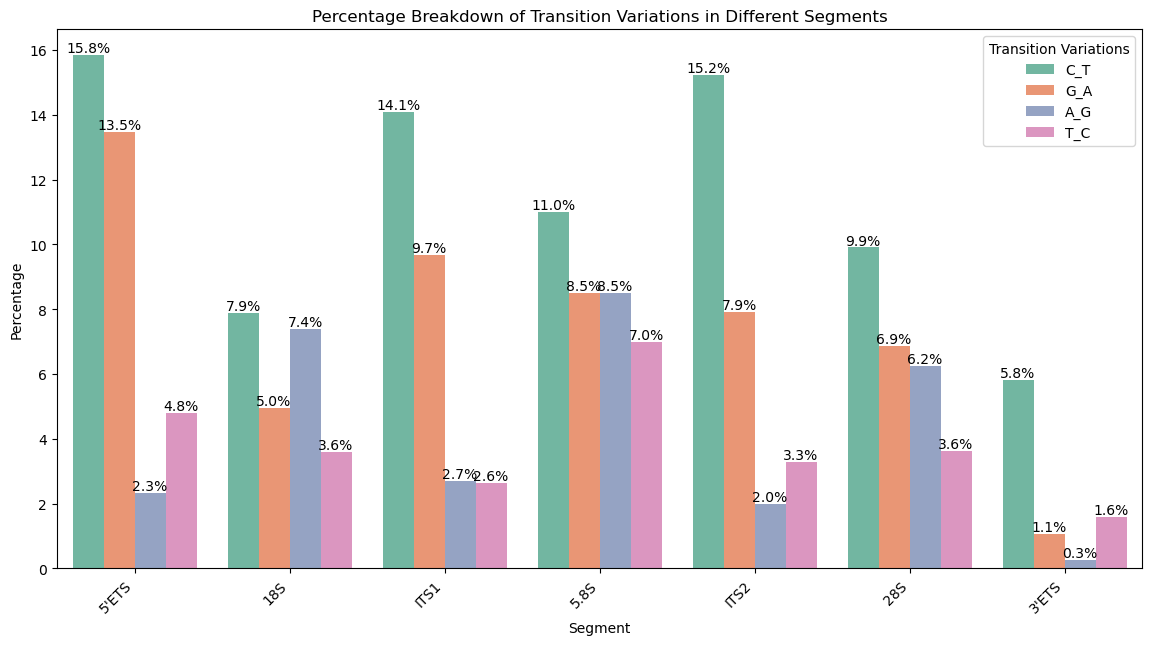

/var/folders/hb/l21bg8lx3tgc5ky3s56cwdth0000gn/T/ipykernel_52943/588001846.py:86: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  ax = sns.barplot(x='Segment', y='Percentage', hue='Variation', data=df[df['Variation'].isin(transversion_vars)], palette='Set2', ci=None)


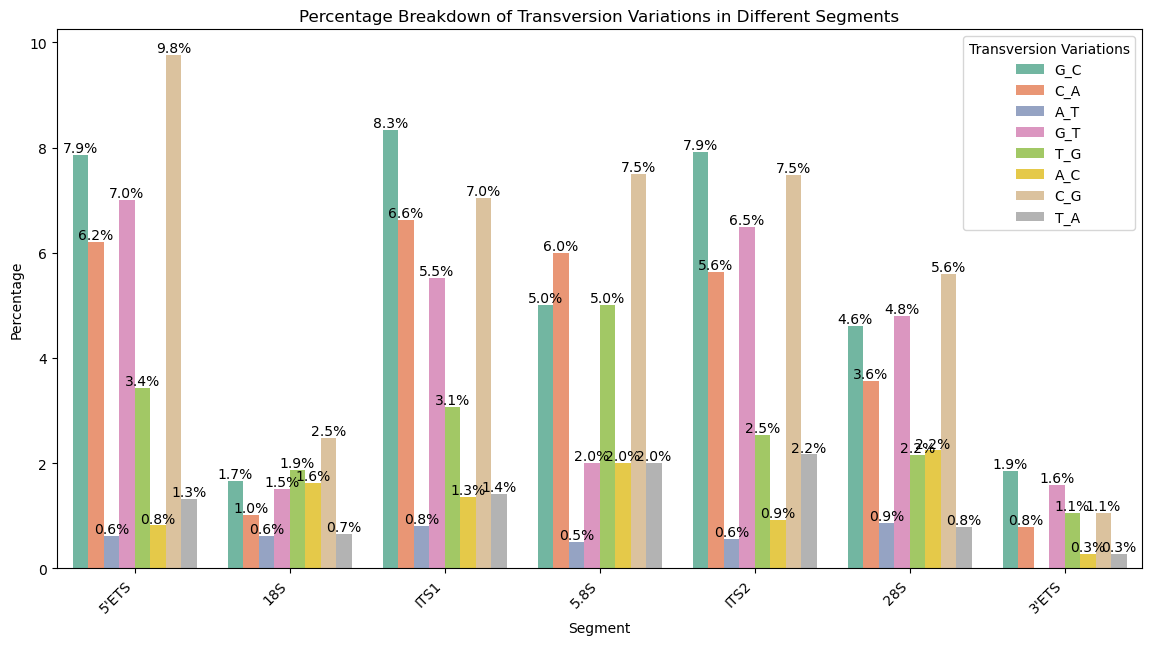

/var/folders/hb/l21bg8lx3tgc5ky3s56cwdth0000gn/T/ipykernel_52943/588001846.py:95: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  ax = sns.barplot(x='Segment', y='Percentage', hue='Variation', data=df[df['Variation'].isin(['indel', 'no_change'])], palette='Set2', ci=None)


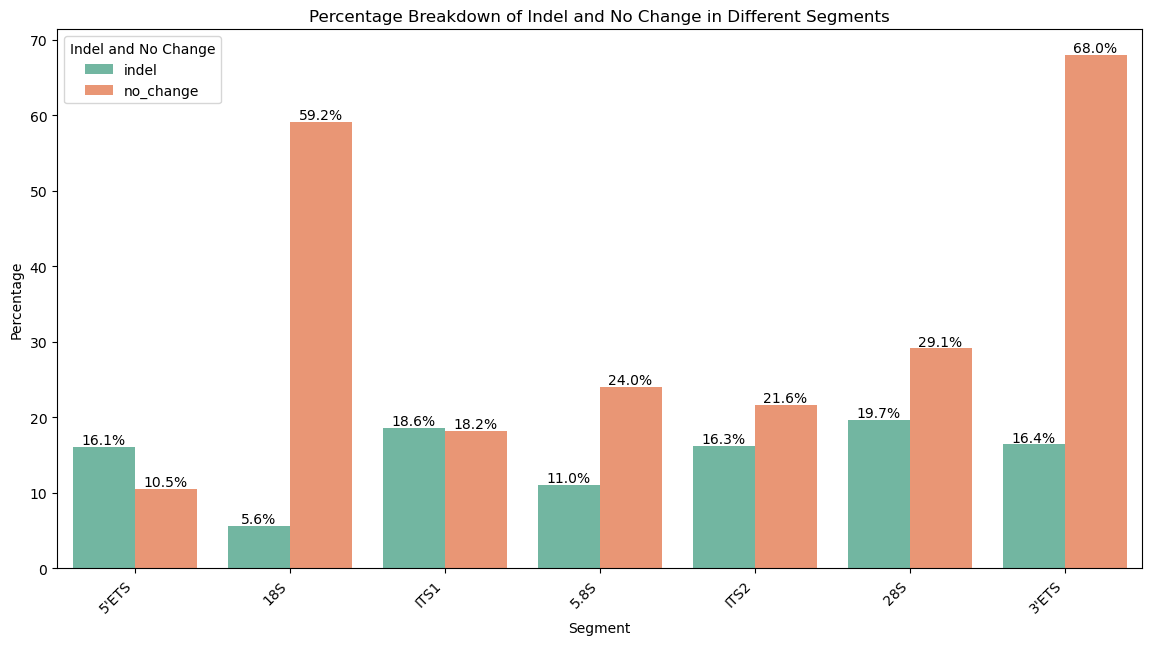

In [32]:
###
#Plot for Percentage Breakdown of Transition Variations in Different Segments - og vcf
#Plot for Percentage Breakdown of Transversion Variations in Different Segments - og vcf
#Percentage Breakdown of Indel and No Change in Different Segments - og vcf
###

# Prepare data for each segment
segment_data = {label: {'transition': {var: 0 for var in transitions},
                        'transversion': {var: 0 for var in transversions},
                        'indel': 0, 'no_change': 0} for _, _, label in all_positions}

# Count occurrences for each segment
for pos in range(1, 13315):
    for start, end, label in all_positions:
        if start <= pos <= end:
            for var in position_data[pos]['transition']:
                segment_data[label]['transition'][var] += 1
            for var in position_data[pos]['transversion']:
                segment_data[label]['transversion'][var] += 1
            segment_data[label]['indel'] += len(position_data[pos]['indel'])
            segment_data[label]['no_change'] += position_data[pos]['no_change']

# Calculate percentages for each segment
segment_percentages = {}
for label in segment_data:
    total_transitions = sum(segment_data[label]['transition'].values())
    total_transversions = sum(segment_data[label]['transversion'].values())
    total_indels = segment_data[label]['indel']
    total_no_changes = segment_data[label]['no_change']
    total_count = total_transitions + total_transversions + total_indels + total_no_changes

    if total_count > 0:
        transition_percentages = {key: (value / total_count) * 100 for key, value in segment_data[label]['transition'].items()}
        transversion_percentages = {key: (value / total_count) * 100 for key, value in segment_data[label]['transversion'].items()}
        indel_percentage = (total_indels / total_count) * 100
        no_change_percentage = (total_no_changes / total_count) * 100
    else:
        transition_percentages = {key: 0 for key in segment_data[label]['transition']}
        transversion_percentages = {key: 0 for key in segment_data[label]['transversion']}
        indel_percentage = no_change_percentage = 0
    
    segment_percentages[label] = {
        'transition': transition_percentages,
        'transversion': transversion_percentages,
        'indel': indel_percentage,
        'no_change': no_change_percentage
    }

# Prepare data for visualization
segments = list(segment_percentages.keys())
transition_vars = list(transitions)
transversion_vars = list(transversions)

# Flatten the data for plotting
flat_data = []
for seg in segments:
    for var in transition_vars:
        flat_data.append((seg, var, segment_percentages[seg]['transition'][var]))
    for var in transversion_vars:
        flat_data.append((seg, var, segment_percentages[seg]['transversion'][var]))
    flat_data.append((seg, 'indel', segment_percentages[seg]['indel']))
    flat_data.append((seg, 'no_change', segment_percentages[seg]['no_change']))

df = pd.DataFrame(flat_data, columns=['Segment', 'Variation', 'Percentage'])

# Function to add percentage labels to the bars
def add_percentage_labels(ax):
    for p in ax.patches:
        if p.get_height() > 0:  # Only add labels for bars with height greater than 0
            percentage = f'{p.get_height():.1f}%'
            x = p.get_x() + p.get_width() / 2
            y = p.get_height()
            ax.annotate(percentage, (x, y), ha='center', va='center', xytext=(0, 5), textcoords='offset points')

# Plotting the transition variations
plt.figure(figsize=(14, 7))
ax = sns.barplot(x='Segment', y='Percentage', hue='Variation', data=df[df['Variation'].isin(transition_vars)], palette='Set2', ci=None)
plt.title('Percentage Breakdown of Transition Variations in Different Segments')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Transition Variations')
add_percentage_labels(ax)
plt.tight_layout()
plt.savefig("transition_breakdown_segments.svg", format="svg", bbox_inches="tight")
# plt.show()

# Plotting the transversion variations
plt.figure(figsize=(14, 7))
ax = sns.barplot(x='Segment', y='Percentage', hue='Variation', data=df[df['Variation'].isin(transversion_vars)], palette='Set2', ci=None)
plt.title('Percentage Breakdown of Transversion Variations in Different Segments')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Transversion Variations')
add_percentage_labels(ax)
plt.tight_layout()
plt.savefig("transversion_breakdown_segments.svg", format="svg", bbox_inches="tight")
# plt.show()

# Plotting indel and no change
plt.figure(figsize=(14, 7))
ax = sns.barplot(x='Segment', y='Percentage', hue='Variation', data=df[df['Variation'].isin(['indel', 'no_change'])], palette='Set2', ci=None)
plt.title('Percentage Breakdown of Indel and No Change in Different Segments')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Indel and No Change')
add_percentage_labels(ax)
plt.tight_layout()
plt.savefig("indel_nochange_breakdown_segments.svg", format="svg", bbox_inches="tight")
# plt.show()


/var/folders/hb/l21bg8lx3tgc5ky3s56cwdth0000gn/T/ipykernel_52943/2280469279.py:53: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  ax = sns.barplot(x='Segment', y='Percentage', hue='Base', data=df, palette='Set2', ci=None)


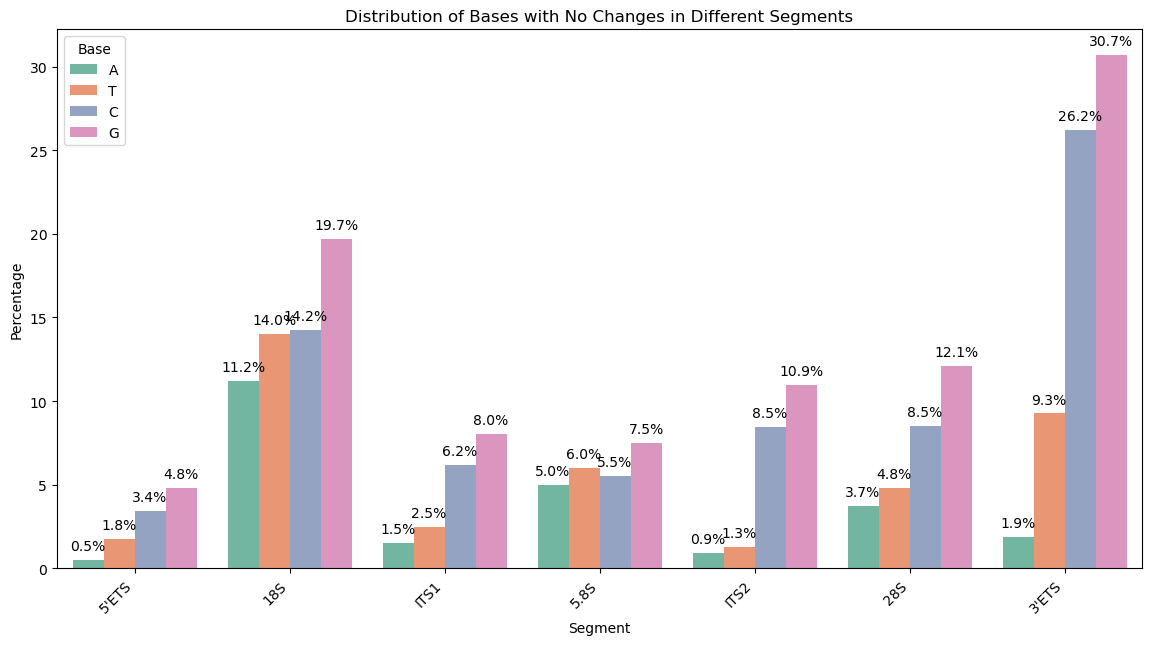

In [ ]:
#Distribution of Bases with No Changes in Different Segments - og ref
og_ref_file = '/Users/fionachow/Documents/NYU/CDS/Summer 2024/Human rDNA Research/Project/Human-rDNA/outputs/src_outputs/og_ref.csv'

# Load the original reference file
og_ref_df = pd.read_csv(og_ref_file)

# Prepare data for each segment
segment_data = {label: {'A': 0, 'T': 0, 'C': 0, 'G': 0} for _, _, label in all_positions} 

# Count no-change bases for each segment
for pos in range(1, 13315):
    base = og_ref_df.loc[og_ref_df['POS'] == pos, 'REF'].values[0]
    if position_data[pos]['no_change'] == 1:
        for start, end, label in all_positions:
            if start <= pos <= end:
                segment_data[label][base] += 1
                # segment_data[label]['no_change'] += 1

# Calculate percentages for each segment
segment_percentages = {}
for label in segment_data:
    total_no_changes = sum(saved_segment_data[label].values())
    if total_no_changes > 0:
        base_percentages = {base: (count / total_no_changes) * 100 for base, count in segment_data[label].items() if base in 'ATCG'}
    else:
        base_percentages = {base: 0 for base in 'ATCG'}
    
    segment_percentages[label] = base_percentages

# Prepare data for visualization
segments = list(segment_percentages.keys())
bases = ['A', 'T', 'C', 'G']

# Flatten the data for plotting
flat_data = []
for seg in segments:
    for base in bases:
        flat_data.append((seg, base, segment_percentages[seg][base]))

df = pd.DataFrame(flat_data, columns=['Segment', 'Base', 'Percentage'])

# Function to add percentage labels to the bars
def add_percentage_labels(ax):
    for p in ax.patches:
        if p.get_height() > 0:  # Only add labels for bars with height greater than 0
            percentage = f'{p.get_height():.1f}%'
            x = p.get_x() + p.get_width() / 2
            y = p.get_height()
            ax.annotate(percentage, (x, y), ha='center', va='bottom', xytext=(0, 5), textcoords='offset points')

# Plotting the distribution of bases with no changes
plt.figure(figsize=(14, 7))
ax = sns.barplot(x='Segment', y='Percentage', hue='Base', data=df, palette='Set2', ci=None)
plt.title('Distribution of Bases with No Changes in Different Segments')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Base')
add_percentage_labels(ax)
plt.tight_layout()
plt.savefig("no_change_base_distribution_segments.svg", format="svg", bbox_inches="tight")
# plt.show()